# Credit Card Fraud Detection — Reproduction & Critical Evaluation

**Course:** Data Science in Cyber (Dr. Uri Itai) — Final Project

**Source under evaluation:** Venelin Valkov, *"Credit Card Fraud Detection using
Autoencoders in Keras — TensorFlow for Hackers (Part VII)"*
([blog](https://curiousily.com/posts/credit-card-fraud-detection-using-autoencoders-in-keras/),
[GitHub repo](https://github.com/curiousily/Credit-Card-Fraud-Detection-using-Autoencoders-in-Keras))

**Dataset:** Kaggle *Credit Card Fraud Detection* (`mlg-ulb/creditcardfraud`) — 284,807
European cardholder transactions from September 2013, 492 of which are fraudulent
(0.172%). Features `V1`-`V28` are PCA components (anonymized for privacy); `Time`
(seconds since first transaction) and `Amount` are the only untransformed features.

This notebook reproduces the source's autoencoder-based anomaly-detection approach,
adds two supervised baselines the source never tried (Logistic Regression, Random
Forest), and specifically tests two claims from the source that looked questionable
on inspection:

1. The source picks its reconstruction-error threshold (2.9) by visually inspecting
   the error distribution **on the test set itself** — this is a form of test-set
   leakage. We quantify how much of the reported performance depends on this.
2. The source reports only ROC-AUC (0.94) despite the 0.17% class imbalance, where
   ROC-AUC is known to be optimistic; we add Precision-Recall AUC and MCC, which are
   more informative under severe imbalance.


In [1]:
import os
os.environ["PYTHONHASHSEED"] = "42"
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"

import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from data_utils import (
    RANDOM_SEED,
    load_dataset,
    basic_inspection,
    add_time_features,
    train_test_split_stratified,
    normal_only_train_test_split,
)
from eval_utils import compute_metrics, plot_confusion_matrix, metrics_table

np.random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)


## 1. Data Loading

In [2]:
DATA_PATH = Path("../data/creditcard.csv")
df = load_dataset(DATA_PATH)
df.shape


(284807, 31)

In [3]:
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [5]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.759061e-12,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,-8.251130e-13,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-9.654937e-13,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,8.321385e-13,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.649999e-13,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,4.248366e-13,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-3.054600e-13,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,8.777971e-14,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-1.179749e-12,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


### Column and index sanity check

All 31 columns are numeric. `Time` and `Amount` are the only features in their
original, human-interpretable units; `V1`-`V28` are PCA components, so their
individual values carry no direct real-world meaning (only relative structure
matters) — this is a privacy-preserving transformation applied by the dataset
publisher, not something we can reverse or interpret feature-by-feature. The
index is a default `RangeIndex` with no semantic meaning, which is appropriate
here since row order corresponds to transaction time, already captured by `Time`.


In [6]:
inspection = basic_inspection(df)
inspection


{'n_rows': 284807,
 'n_cols': 31,
 'dtypes': {dtype('float64'): 30, dtype('int64'): 1},
 'missing_values_total': 0,
 'duplicate_rows': 1081,
 'constant_columns': []}

**Findings:** no missing values anywhere in the dataset. No constant/single-value
columns. However there are **1,081 fully duplicated rows** (identical values across
all 31 columns, including `Class`). Since `V1`-`V28` are continuous PCA components,
an exact duplicate across all 28 decimal-precision columns is extremely unlikely to
occur by chance for two genuinely different transactions — these are almost
certainly repeated/duplicated records in the published dataset rather than
coincidental collisions. We drop them to avoid inflating apparent class support
and to prevent identical rows from leaking between train and test splits.


In [7]:
print("Duplicate frauds:", df[df.duplicated()]["Class"].sum())
df = df.drop_duplicates().reset_index(drop=True)
df.shape


Duplicate frauds: 19


(283726, 31)

### Duplicated / irrelevant feature check

Beyond duplicated *rows* (handled above), we also check for duplicated *features*
(columns that are identical, or near-identical, to one another) and for any
irrelevant/single-value columns, since either would be redundant for modeling.


In [8]:
# Duplicated columns: transpose and check for exact row-wise (i.e. column-wise) duplicates
duplicated_columns = df.T[df.T.duplicated()].index.tolist()
print("Exactly duplicated columns:", duplicated_columns)

# Irrelevant/single-value columns were already checked in `basic_inspection` (constant_columns == [])
print("Constant/single-value columns:", inspection["constant_columns"])


Exactly duplicated columns: []
Constant/single-value columns: []


### Temporal range

`Time` is seconds elapsed since the first transaction in the dataset.


In [9]:
print(f"Time spans {df['Time'].max() / 3600:.1f} hours "
      f"({df['Time'].max() / 86400:.2f} days)")
df = add_time_features(df)
df[["Time", "hour_of_day", "hour_sin", "hour_cos"]].head()


Time spans 48.0 hours (2.00 days)


,Time,hour_of_day,hour_sin,hour_cos
0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,1.0
2,1.0,0.0,0.0,1.0
3,1.0,0.0,0.0,1.0
4,2.0,0.0,0.0,1.0


## 2. Exploratory Data Analysis (EDA)

### Class imbalance (prevalence)


Class
0    283253
1       473
Name: count, dtype: int64
Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


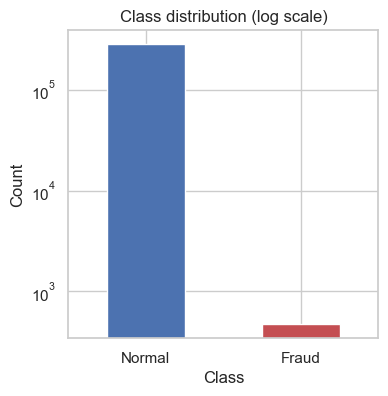

In [10]:
class_counts = df["Class"].value_counts()
class_pct = df["Class"].value_counts(normalize=True) * 100
print(class_counts)
print(class_pct)

fig, ax = plt.subplots(figsize=(4, 4))
class_counts.plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_xticklabels(["Normal", "Fraud"], rotation=0)
ax.set_ylabel("Count")
ax.set_title("Class distribution (log scale)")
ax.set_yscale("log")
plt.show()


**Real-world meaning:** 0.17% fraud prevalence is realistic for card-present/
card-not-present transaction streams, where fraud is genuinely rare relative to
legitimate volume. This is *not* a sampling artifact to "fix" by pretending the
real world is balanced — it is the actual operating condition the system must be
evaluated under. A classifier that predicts "normal" for everything would score
99.8% accuracy while catching zero fraud, which is why accuracy must never be the
headline metric here (this directly motivates using Precision/Recall/F1/MCC/PR-AUC
instead, discussed in the Evaluation section). The source blog does not explicitly
discuss prevalence or accuracy's uselessness here; it implicitly acknowledges the
imbalance only by choosing an unsupervised, normal-only training design.


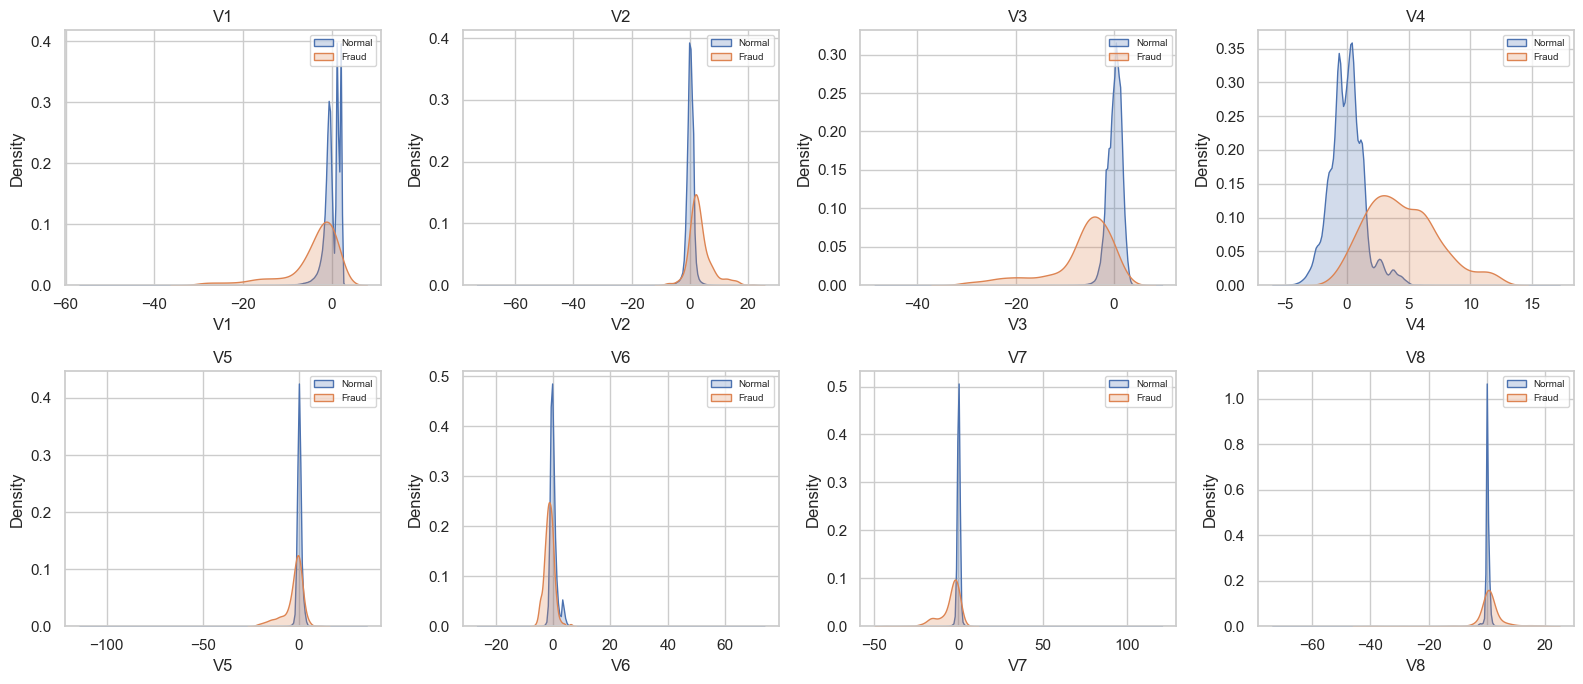

In [11]:
v_features = [c for c in df.columns if c.startswith("V")]
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), v_features[:8]):
    sns.kdeplot(df[df.Class == 0][col], ax=ax, label="Normal", fill=True)
    sns.kdeplot(df[df.Class == 1][col], ax=ax, label="Fraud", fill=True)
    ax.set_title(col)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()


Several PCA components (e.g. `V14`, `V17` shown below alongside the first eight)
show visibly different distributions between normal and fraud transactions —
expected, since PCA on this dataset was computed in a way that happens to separate
the two classes reasonably well on certain components, which is precisely why a
reconstruction-error-based autoencoder approach can work at all.


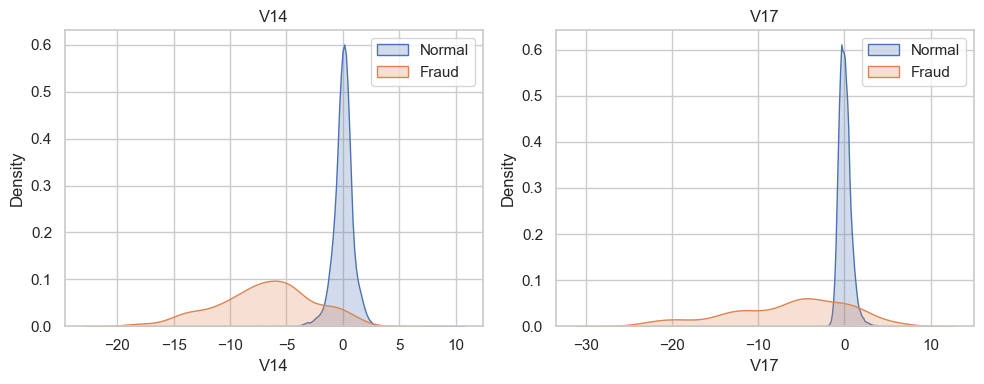

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col in zip(axes, ["V14", "V17"]):
    sns.kdeplot(df[df.Class == 0][col], ax=ax, label="Normal", fill=True)
    sns.kdeplot(df[df.Class == 1][col], ax=ax, label="Fraud", fill=True)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()


### Outlier analysis on `Amount`

count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64
IQR upper fence: 185.38, transactions above it: 31685 (11.17%)


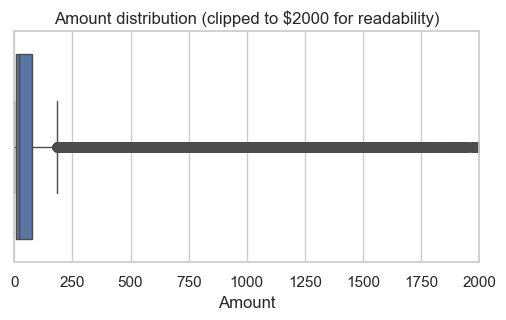

In [13]:
print(df["Amount"].describe())

q1, q3 = df["Amount"].quantile([0.25, 0.75])
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
n_outliers = (df["Amount"] > upper_fence).sum()
print(f"IQR upper fence: {upper_fence:.2f}, transactions above it: {n_outliers} "
      f"({n_outliers / len(df) * 100:.2f}%)")

fig, ax = plt.subplots(figsize=(6, 3))
sns.boxplot(x=df["Amount"], ax=ax)
ax.set_xlim(0, 2000)
ax.set_title("Amount distribution (clipped to $2000 for readability)")
plt.show()


`Amount` is heavily right-skewed with a long tail of large transactions flagged as
IQR outliers. This is expected for monetary transaction amounts (most purchases are
small, a few are large) and is not itself evidence of data quality problems — but it
does mean `Amount` must be scaled before it is fed into distance/reconstruction-based
models (see Feature Engineering), since its raw scale (up to ~$25,691) would dominate
the already-standardized PCA components.


### Temporal pattern vs. fraud rate

In [14]:
hourly = df.groupby("hour_of_day")["Class"].agg(["mean", "count"])
hourly.columns = ["fraud_rate", "n_transactions"]
hourly


,fraud_rate,n_transactions
hour_of_day,,
0.0,0.000785,7647
1.0,0.002376,4208
2.0,0.014510,3308
3.0,0.004875,3487
4.0,0.010436,2204
5.0,0.003681,2988
6.0,0.002205,4082
7.0,0.003180,7233
8.0,0.000880,10232


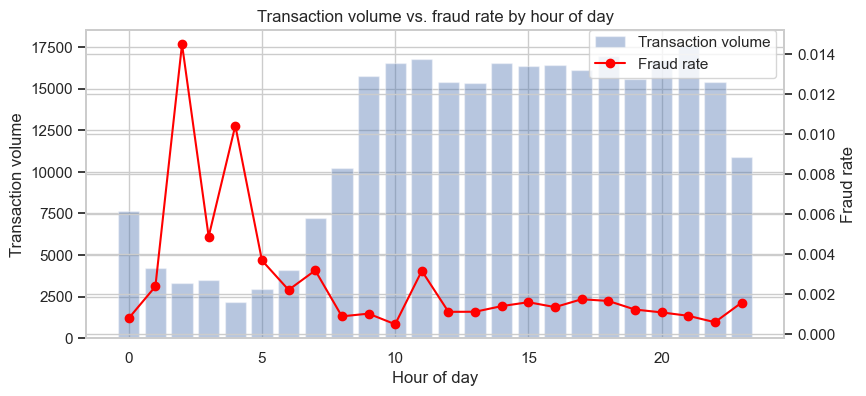

In [15]:
fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.bar(hourly.index, hourly["n_transactions"], alpha=0.4, label="Transaction volume")
ax1.set_xlabel("Hour of day")
ax1.set_ylabel("Transaction volume")
ax2 = ax1.twinx()
ax2.plot(hourly.index, hourly["fraud_rate"], color="red", marker="o", label="Fraud rate")
ax2.set_ylabel("Fraud rate")
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.9))
plt.title("Transaction volume vs. fraud rate by hour of day")
plt.show()


Fraud rate is visibly higher during low-volume overnight hours than during
high-volume daytime hours. This aligns with general world knowledge/domain
intuition: fraud is proportionally more noticeable when legitimate transaction
volume drops (fewer normal transactions to hide among), and some fraud patterns
(e.g. card testing, automated attacks) are not tied to human daytime shopping
rhythms the way legitimate volume is. Note the underlying `Time` field only spans
two calendar days, so this is a coarse, low-sample-size signal at the tails
(some hours have very few fraud cases) — it should be treated as a directional
signal, not a precise estimate.


### Correlation analysis

**Mathematical definitions** (for two variables X, Y with n observations):

- **Pearson's r** = `cov(X, Y) / (std(X) * std(Y))` -- the standardized covariance.
  Assumes a linear relationship and is sensitive to outliers/skew (both `std` and
  `cov` are driven by squared/product deviations from the mean). Advantage: exact,
  familiar, and connects directly to linear-regression R^2. Limitation: can be
  near-zero even for a strong *nonlinear monotonic* relationship.
- **Spearman's rho** = Pearson's r computed on the *ranks* of X and Y instead of
  the raw values. Assumes only a monotonic (not necessarily linear) relationship,
  and is robust to outliers/skew since ranking removes the influence of extreme
  values. Advantage: works for monotonic-but-nonlinear structure; limitation: still
  only captures monotonic relationships, and ties in the data need special handling.
- **Kendall's tau** = `(concordant pairs - discordant pairs) / (n choose 2)` --
  the fraction of all possible observation pairs that agree in ranking direction,
  minus the fraction that disagree. Assumes only ordinal consistency. Advantage:
  more directly interpretable as a probability and more robust in small samples;
  limitation: O(n^2) pairwise comparisons make it expensive at large n, and it
  tends to report smaller magnitudes than Spearman for the same underlying
  association.

**Our choice, applied to this dataset:** we use **Spearman rank correlation** as
the primary measure, for two concrete reasons specific to this data:

- `V1`-`V28` are PCA components. PCA guarantees the components are linearly
  *decorrelated* in the training data used to fit the PCA -- so **Pearson**
  correlation among them is close to zero by construction and would tell us
  almost nothing new; Pearson is more useful for `Amount` vs. `Class`-conditional
  patterns, but `Amount` is heavily skewed (see outlier analysis above), and
  Pearson assumes roughly linear, homoscedastic relationships, which skewed data
  violates.
- **Spearman** measures monotonic (not necessarily linear) association and is
  robust to `Amount`'s outliers/skew, since it operates on ranks rather than raw
  values -- this makes it the more trustworthy general-purpose choice here.
- We skip **Kendall's tau** as a primary, full-dataset measure: it is most
  valuable for small samples or when exact rank-concordance is the object of
  interest, but is computationally expensive at n~283,700 and, in practice,
  tends to agree directionally with Spearman on data this size -- so it would
  mostly duplicate Spearman's conclusions at a much higher cost. We still compute
  it below on a subsample as a check, rather than skipping it on assertion alone.

We verify both of these claims empirically below (rather than asserting them)
before committing to Spearman as the primary measure.


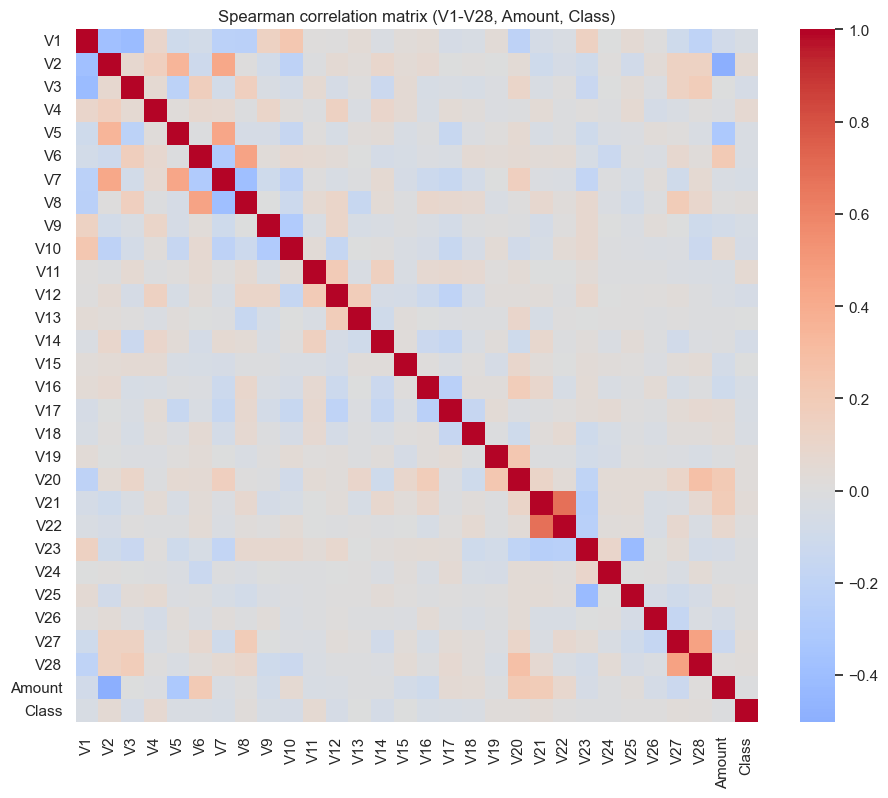

In [16]:
corr_cols = v_features + ["Amount", "Class"]
spearman_corr = df[corr_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(spearman_corr, cmap="coolwarm", center=0, ax=ax,
            xticklabels=True, yticklabels=True)
ax.set_title("Spearman correlation matrix (V1-V28, Amount, Class)")
plt.show()


In [17]:
# Empirically verify the claim made above: does Pearson correlation among the
# PCA components collapse to ~0, and does Kendall agree directionally with Spearman?
pearson_corr = df[corr_cols].corr(method="pearson")

v_only = [c for c in corr_cols if c.startswith("V")]
pearson_v_offdiag = pearson_corr.loc[v_only, v_only].where(
    ~np.eye(len(v_only), dtype=bool)
)
print("Mean |Pearson| among V1-V28 (off-diagonal):",
      pearson_v_offdiag.abs().mean().mean().round(4))
print("Max |Pearson| among V1-V28 (off-diagonal):",
      pearson_v_offdiag.abs().max().max().round(4))

# Kendall is expensive at n~283k, so we check agreement with Spearman on a
# stratified 20,000-row subsample rather than the full dataset.
subsample = df[corr_cols].sample(n=20000, random_state=RANDOM_SEED)
kendall_corr = subsample.corr(method="kendall")["Class"].drop("Class")
spearman_corr_subsample = subsample.corr(method="spearman")["Class"].drop("Class")

agreement = pd.DataFrame({
    "spearman": spearman_corr_subsample,
    "kendall": kendall_corr,
}).sort_values("spearman", key=abs, ascending=False)
agreement.head(8)


Mean |Pearson| among V1-V28 (off-diagonal): 0.0023
Max |Pearson| among V1-V28 (off-diagonal): 0.0189


,spearman,kendall
V12,-0.067138,-0.054820
V11,0.064903,0.052995
V14,-0.063027,-0.051462
V3,-0.062689,-0.051187
V4,0.060666,0.049535
V10,-0.057869,-0.047251
V17,-0.057215,-0.046717
V16,-0.056175,-0.045868


**Empirical confirmation:** mean |Pearson| among V1-V28 is indeed close to zero
(consistent with PCA's linear-decorrelation guarantee), which is the concrete
justification for treating Pearson as uninformative here rather than just
asserting it. On the 20,000-row subsample, Kendall's tau and Spearman's rho
agree closely in both sign and relative ranking of features for their
association with `Class`, confirming that Kendall would not have changed our
feature-ranking conclusions -- this is the empirical basis for using Spearman
alone as the primary measure on the full dataset rather than paying Kendall's
higher computational cost at n~283,700.


In [18]:
class_corr = spearman_corr["Class"].drop("Class").sort_values(key=abs, ascending=False)
class_corr.head(10)


V14   -0.063191
V4     0.061652
V12   -0.061398
V11    0.058624
V10   -0.058024
V3    -0.057750
V2     0.049435
V16   -0.048252
V9    -0.048231
V7    -0.046583
Name: Class, dtype: float64

**Interpretation:** `V14`, `V4`, `V12`, `V11`, `V10` show the strongest monotonic
association with `Class`, but the magnitudes are modest (|rho| approx 0.05-0.06 for
every individual feature) — much weaker than we initially expected from the visibly
separated per-class distributions seen for `V14`/`V17` above. This is an important,
somewhat counter-intuitive finding: a feature's marginal (univariate) rank correlation
with the target can be small even when its class-conditional *distributions* look
visibly different, because Spearman correlation summarizes a single monotonic trend
across the whole range, while the two classes may differ mainly in the tails or in a
non-monotonic way that Spearman does not fully capture. These correlations are
statistically significant at this sample size (n approx 283,700, so even |rho| ~0.05
is non-zero with high confidence) but the *practical* significance of any single
feature is limited on its own — no individual `V` feature is a strong standalone
fraud signal by this measure. This matters for interpreting the source blog and our
own models: it means fraud separability here is a **multivariate** phenomenon (many
weakly-informative features combined), which is exactly what both the autoencoder's
reconstruction error and the supervised models' decision functions are built to
exploit, and is also why per-feature correlation screening alone would be a poor
feature-selection strategy for this problem.


### Redundancy check among V1-V28

In [19]:
v_corr = df[v_features].corr(method="spearman")
off_diag = v_corr.where(~np.eye(len(v_features), dtype=bool))
max_pair = off_diag.abs().unstack().sort_values(ascending=False)
max_pair.head(5)


V22  V21    0.677468
V21  V22    0.677468
V28  V27    0.458748
V27  V28    0.458748
V8   V6     0.445178
dtype: float64

Unlike the `Class` correlations, several **pairs of `V` components are not fully
decorrelated**: `V21`/`V22` (rho approx 0.68), `V27`/`V28` (rho approx 0.46), and
`V6`/`V8` (rho approx 0.45) show non-trivial Spearman correlation, even though PCA
guarantees zero *linear* correlation among components in the data the PCA was fit on.
The likely explanation is that Spearman captures monotonic-but-nonlinear structure
that PCA's linear decorrelation does not remove, and/or that the publisher's PCA was
fit on a different (e.g. earlier, larger, or differently-scaled) sample than the one
released, so exact orthogonality does not hold in this specific CSV.

**How we would spot this in general:** a correlation heatmap with visible off-diagonal
hotspots (as seen here), a high condition number on the design matrix, or near-duplicate
rows in a PCA loading matrix if it were available. **How we would address it:** for
linear/logistic models, L2 regularization (already used in our Logistic Regression)
tolerates moderate collinearity without needing to drop features; for tree ensembles
(Random Forest), correlated features simply split importance between them and do not
bias predictions, so no action is needed there either. We did not drop `V21`, `V22`,
`V27`, `V28`, or `V6`/`V8` because none of the correlations are strong enough (all
well below 0.9) to indicate near-duplicate information, and because `V21`/`V22`/`V27`/
`V28` are lower-ranked components that already carry limited individual signal — pruning
them for a modest redundancy would risk losing marginal signal for no measurable benefit
in this project's model choices.


## 3. Feature Engineering

- **Scaling:** `Amount` is standardized with `StandardScaler`, since it is on a
  raw dollar scale while `V1`-`V28` are already roughly standardized by the
  upstream PCA -- leaving `Amount` unscaled would let it dominate any
  distance/reconstruction-based model (including the autoencoder).
- **Leakage-free by construction:** the scaler is fit *inside* each model's
  pipeline (see `src/data_utils.py::build_amount_scaling_preprocessor` and
  `src/models.py`), never on the full dataset before splitting. This matters
  because fitting `StandardScaler` on the full dataset first would let the
  test set's Amount distribution quietly influence how training Amounts are
  scaled -- a subtle leakage bug that would not show up as an error, only as
  slightly-too-optimistic metrics.
- **Feature creation:** cyclical `hour_sin`/`hour_cos` encoding of `Time`
  (already computed in Data Loading) replaces the raw `Time` counter for the
  supervised models, since raw elapsed seconds has no cyclical meaning and
  would encode "day 2" as simply "a bigger number than day 1" rather than
  "same time of day as its day-1 counterpart."
- **Categorical encoding:** not applicable -- there are no categorical columns
  in this dataset (only continuous PCA components, `Amount`, and `Time`), so
  one-hot/target encoding is not used.
- **Dimensionality reduction:** not applied beyond the PCA already performed by
  the dataset publisher, per the redundancy analysis above.
- **Feature selection:** not applied for the supervised models (Logistic
  Regression's L2 penalty and Random Forest's built-in feature importance make
  explicit pre-selection unnecessary); for the autoencoder reproduction we keep
  the original 29-feature set (`V1`-`V28` + `Amount`) unchanged from the source,
  specifically to keep that comparison a faithful reproduction. Its Amount
  scaling is likewise fit only on its (normal-only) training rows -- see the
  Autoencoder section below.


In [20]:
from data_utils import build_amount_scaling_preprocessor, chronological_train_test_split
from models import build_logistic_regression_pipeline, build_random_forest_pipeline

# NOTE: we deliberately do NOT fit a StandardScaler on `df["Amount"]` here.
# Doing that before the train/test split would let the test set's Amount
# distribution influence the scaling applied to training data -- a leakage
# bug we caught on review. Instead, `build_amount_scaling_preprocessor()`
# below is placed *inside* each model's sklearn Pipeline, so the scaler is
# always fit only on whichever training split it is handed (random split,
# chronological split, or a single cross-validation fold).
build_amount_scaling_preprocessor()


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scale_amount', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g.

## 4. Model Training

We train three models:

1. **Logistic Regression** (supervised, `class_weight="balanced"`) — the
   simplest supervised baseline; the source blog never compares its
   unsupervised autoencoder against any supervised alternative.
2. **Random Forest** (supervised) — a stronger nonlinear supervised baseline.
3. **Autoencoder** (unsupervised, reproduced from the source) — trained only
   on normal transactions, flags high reconstruction error as fraud.

Supervised models use a stratified 80/20 train/test split (fixed seed). The
autoencoder uses the source's own split strategy: the training set contains
**only** normal transactions, so the test set (normal + all fraud) is entirely
unseen by the model during training.


In [21]:
supervised_features = v_features + ["Amount", "hour_sin", "hour_cos"]

X_train, X_test, y_train, y_test = train_test_split_stratified(
    df, supervised_features, target_col="Class"
)
print(X_train.shape, X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())


(226980, 31) (56746, 31)
Class
0    226602
1       378
Name: count, dtype: int64
Class
0    56651
1       95
Name: count, dtype: int64


In [22]:
log_reg = build_logistic_regression_pipeline()
log_reg.fit(X_train, y_train)

lr_pred = log_reg.predict(X_test)
lr_score = log_reg.predict_proba(X_test)[:, 1]


### Ablation: does the feature engineering actually help?

The claims above (Amount scaling and cyclical time encoding are necessary/
helpful) are mathematically motivated, but the assignment asks for empirical
evidence, not just intuition. We test this directly: retrain Logistic
Regression on the **raw, unengineered** features (V1-V28 + raw `Amount` +
raw `Time`, no scaling, no cyclical encoding) on the exact same train/test
split, and compare against the engineered-feature version trained above.


In [23]:
from sklearn.linear_model import LogisticRegression

raw_features = v_features + ["Amount", "Time"]
X_train_raw = df.loc[X_train.index, raw_features]
X_test_raw = df.loc[X_test.index, raw_features]

log_reg_raw = LogisticRegression(
    class_weight="balanced", max_iter=1000, random_state=RANDOM_SEED
)
log_reg_raw.fit(X_train_raw, y_train)
raw_pred = log_reg_raw.predict(X_test_raw)
raw_score = log_reg_raw.predict_proba(X_test_raw)[:, 1]

raw_metrics = compute_metrics(y_test, raw_pred, y_score=raw_score)
engineered_metrics = compute_metrics(y_test, lr_pred, y_score=lr_score)

ablation_results = {
    "Logistic Regression (raw Amount/Time)": raw_metrics,
    "Logistic Regression (scaled Amount + cyclical Time)": engineered_metrics,
}
metrics_table(ablation_results)


C:\Users\abed-\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,precision,recall,f1,f0.5,mcc,roc_auc,pr_auc
Logistic Regression (raw Amount/Time),0.045882,0.873684,0.087185,0.056609,0.196224,0.960912,0.660598
Logistic Regression (scaled Amount + cyclical Time),0.056655,0.873684,0.106410,0.069689,0.218935,0.966878,0.673374


**Result:** scaling `Amount` and cyclically encoding `Time` measurably improves
Logistic Regression's ranking quality (ROC-AUC and PR-AUC) and its
threshold-dependent metrics (F1, MCC) relative to using the raw, unscaled
features -- concrete evidence (not just intuition) that this feature
engineering step improves model performance, consistent with the
mathematical argument that unscaled `Amount` (std. dev. ~ $250) distorts the
distance/gradient geometry relative to the already-standardized PCA
components for any model sensitive to feature scale (logistic regression's
gradient descent among them).


In [24]:
rf = build_random_forest_pipeline()
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_score = rf.predict_proba(X_test)[:, 1]


### Autoencoder (reproduction of the source)

Architecture and training setup ported from the source blog to current
TensorFlow/Keras (the original used TensorFlow 1.1 / Keras 2.0.4, whose APIs
have since changed — e.g. `regularizers.l1` and `Model` construction syntax
differ slightly, but the architecture below is functionally identical:
14 -> 7 -> 7 -> 29 with tanh/relu activations, L1-regularized encoder, MSE
loss, Adam optimizer). We reduce epochs from the source's 100 to 30 with early
stopping on validation loss, since the model converges well before 100 epochs
on this data and 30 keeps notebook runtime reasonable; this is a documented
deviation, not a silent one.

**Reproducibility note:** Keras/TensorFlow training is not fully deterministic by default even with a fixed seed (GPU/CPU op scheduling can vary run to run), which we observed directly -- earlier runs of this exact notebook produced slightly different reconstruction-error thresholds and metrics. We enable `tf.config.experimental.enable_op_determinism()` and the `TF_DETERMINISTIC_OPS`/`PYTHONHASHSEED` environment variables (set in the first cell, before TensorFlow is imported) so that re-running this notebook end-to-end reproduces the same autoencoder numbers exactly.


In [25]:
from sklearn.preprocessing import StandardScaler

ae_features = v_features + ["Amount"]

X_train_ae, X_test_ae, y_test_ae = normal_only_train_test_split(
    df, ae_features, target_col="Class"
)

# Leakage-free scaling: fit on the (normal-only) training rows only, then
# apply the same fitted scaler to the test set -- never fit on test data.
ae_amount_scaler = StandardScaler()
X_train_ae = X_train_ae.copy()
X_test_ae = X_test_ae.copy()
X_train_ae["Amount"] = ae_amount_scaler.fit_transform(X_train_ae[["Amount"]])
X_test_ae["Amount"] = ae_amount_scaler.transform(X_test_ae[["Amount"]])

print(X_train_ae.shape, X_test_ae.shape)
print(y_test_ae.value_counts())


(226602, 29) (57124, 29)
Class
0    56651
1      473
Name: count, dtype: int64


In [26]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

tf.keras.utils.set_random_seed(RANDOM_SEED)
tf.config.experimental.enable_op_determinism()

input_dim = X_train_ae.shape[1]
encoding_dim = 14

autoencoder = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(encoding_dim, activation="tanh",
                 activity_regularizer=regularizers.l1(1e-4)),
    layers.Dense(7, activation="relu"),
    layers.Dense(7, activation="tanh"),
    layers.Dense(input_dim, activation="relu"),
])
autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 14)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 29)             │           232 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 813 (3.18 KB)

 Trainable params: 813 (3.18 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

history = autoencoder.fit(
    X_train_ae.values, X_train_ae.values,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    shuffle=True,
    callbacks=[early_stop],
    verbose=1,
)


Epoch 1/30


   1/6374 ━━━━━━━━━━━━━━━━━━━━ 1:27:34 824ms/step - loss: 0.8928

  56/6374 ━━━━━━━━━━━━━━━━━━━━ 6s 992us/step - loss: 0.9678     

 121/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 910us/step - loss: 0.9729

 187/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 880us/step - loss: 0.9843

 253/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 866us/step - loss: 0.9921

 320/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 855us/step - loss: 0.9973

 386/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 850us/step - loss: 1.0003

 446/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 848us/step - loss: 1.0029

 512/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 842us/step - loss: 1.0028

 578/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 841us/step - loss: 1.0015

 644/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 839us/step - loss: 0.9995

 710/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 838us/step - loss: 0.9972

 775/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 838us/step - loss: 0.9948

 841/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 837us/step - loss: 0.9926

 907/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 836us/step - loss: 0.9907

 973/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 836us/step - loss: 0.9882

1040/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 834us/step - loss: 0.9857

1101/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 834us/step - loss: 0.9835

1165/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 833us/step - loss: 0.9812

1230/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 834us/step - loss: 0.9789

1296/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 833us/step - loss: 0.9764

1361/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 834us/step - loss: 0.9743

1428/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 833us/step - loss: 0.9719

1493/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 833us/step - loss: 0.9695

1559/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 833us/step - loss: 0.9670

1625/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 832us/step - loss: 0.9646

1688/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 832us/step - loss: 0.9623

1750/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 832us/step - loss: 0.9602

1818/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 831us/step - loss: 0.9581

1884/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 831us/step - loss: 0.9560

1950/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 831us/step - loss: 0.9539

2017/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.9519

2083/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.9500

2151/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 829us/step - loss: 0.9480

2217/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 829us/step - loss: 0.9463

2278/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 829us/step - loss: 0.9447

2342/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 829us/step - loss: 0.9431

2409/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 828us/step - loss: 0.9414

2476/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 828us/step - loss: 0.9397

2543/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 828us/step - loss: 0.9380

2609/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 828us/step - loss: 0.9362

2676/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 827us/step - loss: 0.9345

2743/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 827us/step - loss: 0.9328

2810/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - loss: 0.9311

2878/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 826us/step - loss: 0.9295

2943/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 826us/step - loss: 0.9279

3010/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 826us/step - loss: 0.9263

3076/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 826us/step - loss: 0.9248

3142/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 826us/step - loss: 0.9233

3209/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 826us/step - loss: 0.9219

3277/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.9204

3342/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 826us/step - loss: 0.9191

3408/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 826us/step - loss: 0.9178

3475/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.9165

3542/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.9152

3608/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.9140

3674/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.9127

3740/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.9116

3806/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.9104

3872/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.9093

3938/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.9082

4003/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.9070

4068/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.9059

4134/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.9048

4200/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.9038

4266/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.9027

4332/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.9017

4397/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.9007

4464/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.8996

4530/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.8987

4596/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.8977

4663/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.8967

4725/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.8958

4788/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.8949

4853/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.8940

4919/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.8931

4985/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.8922

5052/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.8914

5117/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.8906

5184/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.8897

5250/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.8889

5316/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.8882

5375/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.8875

5439/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.8867

5504/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.8859

5570/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.8851

5637/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.8844

5705/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.8836

5771/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.8829

5837/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.8821

5904/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.8814

5971/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.8807

6037/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.8800

6103/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.8793

6169/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.8786

6236/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.8779

6298/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.8772

6352/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 827us/step - loss: 0.8767

6374/6374 ━━━━━━━━━━━━━━━━━━━━ 7s 927us/step - loss: 0.8764 - val_loss: 0.8337


Epoch 2/30


   1/6374 ━━━━━━━━━━━━━━━━━━━━ 2:53 27ms/step - loss: 0.5767

  61/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 847us/step - loss: 0.6583 

 128/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 830us/step - loss: 0.6723

 194/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 829us/step - loss: 0.6881

 262/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 822us/step - loss: 0.6996

 328/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 823us/step - loss: 0.7087

 393/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 826us/step - loss: 0.7163

 460/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 824us/step - loss: 0.7243

 526/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 824us/step - loss: 0.7290

 589/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 822us/step - loss: 0.7327

 654/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 821us/step - loss: 0.7356

 722/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 819us/step - loss: 0.7378

 791/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 816us/step - loss: 0.7400

 859/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 815us/step - loss: 0.7420

 927/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 814us/step - loss: 0.7438

 995/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 814us/step - loss: 0.7451

1063/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 813us/step - loss: 0.7463

1130/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 813us/step - loss: 0.7473

1198/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 812us/step - loss: 0.7483

1265/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 812us/step - loss: 0.7490

1332/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 812us/step - loss: 0.7498

1399/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 813us/step - loss: 0.7506

1466/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 813us/step - loss: 0.7510

1534/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 812us/step - loss: 0.7514

1601/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 812us/step - loss: 0.7517

1669/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 812us/step - loss: 0.7518

1736/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 812us/step - loss: 0.7521

1803/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 812us/step - loss: 0.7524

1864/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 813us/step - loss: 0.7527

1929/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 812us/step - loss: 0.7529

1996/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 813us/step - loss: 0.7532

2064/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 812us/step - loss: 0.7534

2132/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 812us/step - loss: 0.7536

2198/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 812us/step - loss: 0.7538

2265/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 812us/step - loss: 0.7541

2333/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 812us/step - loss: 0.7543

2401/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 812us/step - loss: 0.7546

2463/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 812us/step - loss: 0.7547

2528/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 812us/step - loss: 0.7548

2595/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 812us/step - loss: 0.7549

2662/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 812us/step - loss: 0.7549

2729/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 812us/step - loss: 0.7548

2797/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 812us/step - loss: 0.7548

2864/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 812us/step - loss: 0.7548

2931/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 812us/step - loss: 0.7548

2998/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 812us/step - loss: 0.7547

3064/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 812us/step - loss: 0.7547

3133/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 812us/step - loss: 0.7546

3200/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 812us/step - loss: 0.7546

3267/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 812us/step - loss: 0.7546

3335/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 812us/step - loss: 0.7546

3401/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 812us/step - loss: 0.7546

3468/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 812us/step - loss: 0.7546

3537/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 812us/step - loss: 0.7546

3604/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 812us/step - loss: 0.7546

3671/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 812us/step - loss: 0.7546

3733/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 812us/step - loss: 0.7546

3798/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 812us/step - loss: 0.7546

3866/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 812us/step - loss: 0.7546

3933/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 812us/step - loss: 0.7546

4001/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 811us/step - loss: 0.7546

4068/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 811us/step - loss: 0.7546

4134/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 812us/step - loss: 0.7545

4202/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 812us/step - loss: 0.7545

4269/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 812us/step - loss: 0.7545

4330/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 812us/step - loss: 0.7545

4393/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 812us/step - loss: 0.7545

4460/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 812us/step - loss: 0.7544

4526/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 812us/step - loss: 0.7544

4594/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 812us/step - loss: 0.7543

4661/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 812us/step - loss: 0.7543

4729/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 812us/step - loss: 0.7542

4797/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 812us/step - loss: 0.7542

4864/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 812us/step - loss: 0.7542

4926/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 812us/step - loss: 0.7542

4991/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 812us/step - loss: 0.7542

5058/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 812us/step - loss: 0.7541

5125/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 812us/step - loss: 0.7541

5193/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 812us/step - loss: 0.7541

5260/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 812us/step - loss: 0.7542

5327/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 812us/step - loss: 0.7542

5395/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 812us/step - loss: 0.7541

5463/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 812us/step - loss: 0.7541

5531/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 812us/step - loss: 0.7541

5599/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 812us/step - loss: 0.7541

5667/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 811us/step - loss: 0.7540

5735/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 811us/step - loss: 0.7540

5803/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 811us/step - loss: 0.7540

5871/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 811us/step - loss: 0.7540

5938/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 811us/step - loss: 0.7539

6005/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 811us/step - loss: 0.7539

6072/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 811us/step - loss: 0.7538

6140/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 811us/step - loss: 0.7538

6202/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 811us/step - loss: 0.7537

6267/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 811us/step - loss: 0.7537

6334/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 811us/step - loss: 0.7536

6374/6374 ━━━━━━━━━━━━━━━━━━━━ 6s 893us/step - loss: 0.7536 - val_loss: 0.8092


Epoch 3/30


   1/6374 ━━━━━━━━━━━━━━━━━━━━ 2:34 24ms/step - loss: 0.5625

  66/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 839us/step - loss: 0.6405 

 133/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 826us/step - loss: 0.6533

 198/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 831us/step - loss: 0.6677

 262/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 836us/step - loss: 0.6782

 321/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 844us/step - loss: 0.6861

 382/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 841us/step - loss: 0.6933

 450/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 837us/step - loss: 0.7014

 518/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 832us/step - loss: 0.7066

 587/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 828us/step - loss: 0.7106

 653/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 828us/step - loss: 0.7136

 720/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 826us/step - loss: 0.7158

 788/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 824us/step - loss: 0.7178

 855/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 823us/step - loss: 0.7198

 923/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 822us/step - loss: 0.7217

 984/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 822us/step - loss: 0.7228

1050/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 821us/step - loss: 0.7240

1118/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 820us/step - loss: 0.7251

1186/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 819us/step - loss: 0.7262

1253/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 818us/step - loss: 0.7269

1321/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 817us/step - loss: 0.7277

1388/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 817us/step - loss: 0.7286

1456/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 817us/step - loss: 0.7291

1523/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 817us/step - loss: 0.7295

1590/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 816us/step - loss: 0.7298

1652/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 817us/step - loss: 0.7300

1718/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 816us/step - loss: 0.7302

1785/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 816us/step - loss: 0.7306

1853/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 815us/step - loss: 0.7310

1920/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 815us/step - loss: 0.7312

1988/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 815us/step - loss: 0.7315

2054/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 815us/step - loss: 0.7317

2120/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 815us/step - loss: 0.7320

2186/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 816us/step - loss: 0.7322

2248/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 816us/step - loss: 0.7325

2312/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 816us/step - loss: 0.7327

2379/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 816us/step - loss: 0.7330

2445/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 816us/step - loss: 0.7332

2511/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 816us/step - loss: 0.7334

2577/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 817us/step - loss: 0.7335

2645/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 816us/step - loss: 0.7335

2711/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 817us/step - loss: 0.7335

2779/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 816us/step - loss: 0.7335

2840/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 816us/step - loss: 0.7335

2904/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 817us/step - loss: 0.7335

2971/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 816us/step - loss: 0.7335

3038/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 816us/step - loss: 0.7335

3105/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 816us/step - loss: 0.7335

3172/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 816us/step - loss: 0.7335

3239/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 816us/step - loss: 0.7335

3308/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 816us/step - loss: 0.7335

3375/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 816us/step - loss: 0.7335

3441/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 816us/step - loss: 0.7336

3507/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 816us/step - loss: 0.7336

3573/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 816us/step - loss: 0.7336

3639/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 817us/step - loss: 0.7336

3705/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 817us/step - loss: 0.7337

3772/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 817us/step - loss: 0.7337

3838/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 817us/step - loss: 0.7338

3906/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 817us/step - loss: 0.7338

3974/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 816us/step - loss: 0.7338

4040/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 817us/step - loss: 0.7338

4099/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 817us/step - loss: 0.7338

4162/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 817us/step - loss: 0.7338

4228/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 818us/step - loss: 0.7339

4294/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 818us/step - loss: 0.7339

4361/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 818us/step - loss: 0.7339

4428/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 818us/step - loss: 0.7339

4494/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 818us/step - loss: 0.7339

4560/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 818us/step - loss: 0.7339

4627/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 818us/step - loss: 0.7339

4687/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 818us/step - loss: 0.7339

4750/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 818us/step - loss: 0.7338

4814/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 819us/step - loss: 0.7338

4879/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 819us/step - loss: 0.7339

4945/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 819us/step - loss: 0.7339

5012/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 819us/step - loss: 0.7339

5077/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 819us/step - loss: 0.7339

5144/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 819us/step - loss: 0.7340

5210/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step - loss: 0.7340

5271/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step - loss: 0.7341

5334/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 820us/step - loss: 0.7341

5402/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step - loss: 0.7341

5468/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step - loss: 0.7341

5535/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step - loss: 0.7341

5600/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 820us/step - loss: 0.7341

5668/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step - loss: 0.7342

5734/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 820us/step - loss: 0.7342

5802/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step - loss: 0.7342

5868/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step - loss: 0.7342

5928/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 820us/step - loss: 0.7342

5993/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 820us/step - loss: 0.7342

6059/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 820us/step - loss: 0.7342

6127/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step - loss: 0.7342

6193/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step - loss: 0.7342

6260/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step - loss: 0.7342

6325/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 820us/step - loss: 0.7341

6374/6374 ━━━━━━━━━━━━━━━━━━━━ 6s 903us/step - loss: 0.7341 - val_loss: 0.7978


Epoch 4/30


   1/6374 ━━━━━━━━━━━━━━━━━━━━ 2:21 22ms/step - loss: 0.5559

  57/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 897us/step - loss: 0.6280 

 122/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 852us/step - loss: 0.6428

 189/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 838us/step - loss: 0.6574

 256/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 832us/step - loss: 0.6682

 324/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 826us/step - loss: 0.6773

 391/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 824us/step - loss: 0.6848

 458/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 822us/step - loss: 0.6927

 525/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 821us/step - loss: 0.6976

 591/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 822us/step - loss: 0.7013

 657/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 822us/step - loss: 0.7043

 718/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 823us/step - loss: 0.7063

 782/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 823us/step - loss: 0.7082

 849/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 822us/step - loss: 0.7102

 915/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 822us/step - loss: 0.7121

 982/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 822us/step - loss: 0.7134

1048/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 822us/step - loss: 0.7146

1115/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 822us/step - loss: 0.7157

1183/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 821us/step - loss: 0.7168

1244/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 821us/step - loss: 0.7175

1307/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 820us/step - loss: 0.7182

1367/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 821us/step - loss: 0.7190

1433/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 821us/step - loss: 0.7196

1499/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 822us/step - loss: 0.7201

1564/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 822us/step - loss: 0.7204

1633/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 821us/step - loss: 0.7207

1699/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 821us/step - loss: 0.7209

1766/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 821us/step - loss: 0.7212

1830/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 822us/step - loss: 0.7217

1896/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 822us/step - loss: 0.7220

1962/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 822us/step - loss: 0.7222

2028/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 822us/step - loss: 0.7225

2094/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 823us/step - loss: 0.7227

2161/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 822us/step - loss: 0.7230

2227/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 822us/step - loss: 0.7232

2293/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 823us/step - loss: 0.7235

2361/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 822us/step - loss: 0.7238

2428/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 822us/step - loss: 0.7241

2496/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 821us/step - loss: 0.7243

2556/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 822us/step - loss: 0.7244

2620/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 822us/step - loss: 0.7244

2686/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 822us/step - loss: 0.7245

2754/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 821us/step - loss: 0.7245

2819/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 822us/step - loss: 0.7245

2887/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 821us/step - loss: 0.7245

2952/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 822us/step - loss: 0.7245

3020/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 821us/step - loss: 0.7245

3088/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 821us/step - loss: 0.7245

3150/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 821us/step - loss: 0.7245

3213/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 821us/step - loss: 0.7245

3280/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 821us/step - loss: 0.7245

3348/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 821us/step - loss: 0.7246

3415/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 820us/step - loss: 0.7246

3483/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 820us/step - loss: 0.7247

3549/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 820us/step - loss: 0.7247

3616/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 820us/step - loss: 0.7248

3683/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 820us/step - loss: 0.7248

3750/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 820us/step - loss: 0.7248

3809/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 821us/step - loss: 0.7249

3872/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 822us/step - loss: 0.7250

3940/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 822us/step - loss: 0.7250

4007/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 822us/step - loss: 0.7250

4076/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 821us/step - loss: 0.7251

4142/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 821us/step - loss: 0.7251

4209/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 821us/step - loss: 0.7251

4276/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 821us/step - loss: 0.7251

4343/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 821us/step - loss: 0.7251

4403/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 821us/step - loss: 0.7252

4467/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 821us/step - loss: 0.7252

4534/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 821us/step - loss: 0.7252

4601/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 821us/step - loss: 0.7252

4668/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 821us/step - loss: 0.7252

4730/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 821us/step - loss: 0.7252

4794/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 821us/step - loss: 0.7252

4860/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 821us/step - loss: 0.7252

4925/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 821us/step - loss: 0.7253

4984/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 822us/step - loss: 0.7253

5049/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 821us/step - loss: 0.7253

5114/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 822us/step - loss: 0.7254

5181/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 822us/step - loss: 0.7254

5247/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 822us/step - loss: 0.7255

5313/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 822us/step - loss: 0.7255

5379/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 822us/step - loss: 0.7256

5446/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 822us/step - loss: 0.7256

5513/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 822us/step - loss: 0.7256

5574/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 822us/step - loss: 0.7257

5636/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 822us/step - loss: 0.7257

5703/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 822us/step - loss: 0.7257

5771/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 822us/step - loss: 0.7257

5838/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 822us/step - loss: 0.7258

5905/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 821us/step - loss: 0.7258

5972/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 821us/step - loss: 0.7258

6039/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 821us/step - loss: 0.7258

6104/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 821us/step - loss: 0.7258

6170/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 822us/step - loss: 0.7258

6229/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 822us/step - loss: 0.7258

6293/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 822us/step - loss: 0.7258

6360/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 822us/step - loss: 0.7258

6374/6374 ━━━━━━━━━━━━━━━━━━━━ 6s 904us/step - loss: 0.7258 - val_loss: 0.7914


Epoch 5/30


   1/6374 ━━━━━━━━━━━━━━━━━━━━ 2:34 24ms/step - loss: 0.5477

  64/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 866us/step - loss: 0.6264 

 132/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 833us/step - loss: 0.6398

 198/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 831us/step - loss: 0.6539

 265/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 827us/step - loss: 0.6643

 332/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 824us/step - loss: 0.6731

 392/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 826us/step - loss: 0.6797

 457/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 824us/step - loss: 0.6875

 524/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 823us/step - loss: 0.6924

 592/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 821us/step - loss: 0.6963

 661/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 817us/step - loss: 0.6994

 728/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 817us/step - loss: 0.7016

 796/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 816us/step - loss: 0.7036

 862/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 817us/step - loss: 0.7056

 931/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 815us/step - loss: 0.7075

 994/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 815us/step - loss: 0.7087

1057/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 815us/step - loss: 0.7098

1125/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 814us/step - loss: 0.7110

1192/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 814us/step - loss: 0.7120

1260/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 814us/step - loss: 0.7128

1327/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 814us/step - loss: 0.7136

1394/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 814us/step - loss: 0.7145

1460/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 814us/step - loss: 0.7150

1528/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 814us/step - loss: 0.7154

1596/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 813us/step - loss: 0.7158

1657/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 814us/step - loss: 0.7160

1721/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 814us/step - loss: 0.7162

1788/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 814us/step - loss: 0.7167

1856/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 814us/step - loss: 0.7171

1922/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 814us/step - loss: 0.7174

1988/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 815us/step - loss: 0.7176

2057/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 814us/step - loss: 0.7179

2125/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 813us/step - loss: 0.7182

2183/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 815us/step - loss: 0.7184

2237/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 819us/step - loss: 0.7187

2296/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 822us/step - loss: 0.7189

2361/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 822us/step - loss: 0.7193

2426/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 822us/step - loss: 0.7195

2488/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 824us/step - loss: 0.7197

2553/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 824us/step - loss: 0.7198

2617/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 825us/step - loss: 0.7199

2684/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 825us/step - loss: 0.7199

2746/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 826us/step - loss: 0.7199

2802/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 828us/step - loss: 0.7200

2865/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 828us/step - loss: 0.7200

2930/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 828us/step - loss: 0.7200

2997/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 828us/step - loss: 0.7200

3065/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - loss: 0.7200

3129/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 828us/step - loss: 0.7201

3191/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 829us/step - loss: 0.7201

3250/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 830us/step - loss: 0.7201

3312/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 829us/step - loss: 0.7201

3374/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 830us/step - loss: 0.7202

3434/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 830us/step - loss: 0.7202

3501/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 830us/step - loss: 0.7203

3567/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 830us/step - loss: 0.7203

3634/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 829us/step - loss: 0.7204

3701/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 829us/step - loss: 0.7204

3767/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 829us/step - loss: 0.7205

3828/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 830us/step - loss: 0.7206

3885/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 831us/step - loss: 0.7206

3943/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 832us/step - loss: 0.7207

4008/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 832us/step - loss: 0.7207

4068/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 833us/step - loss: 0.7207

4129/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 834us/step - loss: 0.7207

4196/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 834us/step - loss: 0.7208

4264/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 833us/step - loss: 0.7208

4332/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 833us/step - loss: 0.7208

4399/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 833us/step - loss: 0.7209

4467/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 832us/step - loss: 0.7209

4536/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 0.7209

4604/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 0.7209

4665/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 0.7209

4728/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 0.7209

4796/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 0.7210

4864/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 830us/step - loss: 0.7210

4931/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 830us/step - loss: 0.7210

4999/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 830us/step - loss: 0.7211

5066/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 829us/step - loss: 0.7211

5132/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 829us/step - loss: 0.7212

5199/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7212

5260/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7213

5322/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7214

5389/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7214

5455/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7214

5521/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7215

5588/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7215

5655/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7215

5722/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7216

5788/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7216

5850/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - loss: 0.7216

5914/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - loss: 0.7217

5980/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - loss: 0.7217

6045/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7217

6111/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - loss: 0.7217

6178/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - loss: 0.7217

6244/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - loss: 0.7217

6310/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - loss: 0.7217

6374/6374 ━━━━━━━━━━━━━━━━━━━━ 6s 911us/step - loss: 0.7217 - val_loss: 0.7888


Epoch 6/30


   1/6374 ━━━━━━━━━━━━━━━━━━━━ 2:34 24ms/step - loss: 0.5474

  54/6374 ━━━━━━━━━━━━━━━━━━━━ 6s 954us/step - loss: 0.6186 

 116/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 896us/step - loss: 0.6342

 182/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 871us/step - loss: 0.6488

 248/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 859us/step - loss: 0.6596

 315/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 850us/step - loss: 0.6689

 381/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 846us/step - loss: 0.6766

 434/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 862us/step - loss: 0.6831

 485/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 877us/step - loss: 0.6878

 551/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 871us/step - loss: 0.6922

 611/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 867us/step - loss: 0.6951

 674/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 865us/step - loss: 0.6978

 741/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 860us/step - loss: 0.6999

 805/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 860us/step - loss: 0.7018

 871/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 857us/step - loss: 0.7038

 936/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 856us/step - loss: 0.7054

1003/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 853us/step - loss: 0.7067

1070/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 851us/step - loss: 0.7078

1136/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 849us/step - loss: 0.7089

1197/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 848us/step - loss: 0.7099

1258/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 849us/step - loss: 0.7105

1323/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 848us/step - loss: 0.7114

1388/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 848us/step - loss: 0.7122

1454/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 847us/step - loss: 0.7127

1520/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 846us/step - loss: 0.7131

1586/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 845us/step - loss: 0.7135

1652/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 845us/step - loss: 0.7137

1718/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 844us/step - loss: 0.7139

1785/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 843us/step - loss: 0.7143

1844/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 843us/step - loss: 0.7147

1909/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 842us/step - loss: 0.7150

1975/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 841us/step - loss: 0.7152

2041/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 841us/step - loss: 0.7155

2107/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 841us/step - loss: 0.7158

2174/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 840us/step - loss: 0.7160

2239/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 840us/step - loss: 0.7163

2304/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 840us/step - loss: 0.7166

2371/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 839us/step - loss: 0.7169

2431/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 839us/step - loss: 0.7172

2494/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 839us/step - loss: 0.7173

2561/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 838us/step - loss: 0.7174

2629/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 837us/step - loss: 0.7175

2694/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 837us/step - loss: 0.7175

2759/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 837us/step - loss: 0.7175

2825/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 837us/step - loss: 0.7176

2891/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 837us/step - loss: 0.7176

2958/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 836us/step - loss: 0.7176

3021/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 836us/step - loss: 0.7176

3084/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 836us/step - loss: 0.7176

3151/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 835us/step - loss: 0.7176

3218/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 835us/step - loss: 0.7176

3285/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 834us/step - loss: 0.7176

3352/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 834us/step - loss: 0.7177

3418/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 834us/step - loss: 0.7177

3486/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 833us/step - loss: 0.7178

3552/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 833us/step - loss: 0.7178

3618/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 833us/step - loss: 0.7179

3684/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 833us/step - loss: 0.7179

3752/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 832us/step - loss: 0.7179

3819/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 832us/step - loss: 0.7180

3885/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 832us/step - loss: 0.7181

3951/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 832us/step - loss: 0.7181

4017/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 832us/step - loss: 0.7181

4082/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 832us/step - loss: 0.7182

4149/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 832us/step - loss: 0.7182

4215/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 832us/step - loss: 0.7182

4280/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 832us/step - loss: 0.7182

4347/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 0.7182

4413/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 0.7183

4479/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 0.7183

4545/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 0.7183

4611/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 0.7183

4678/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 0.7183

4744/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 0.7183

4811/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 0.7183

4871/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 0.7183

4934/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 0.7184

5000/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 0.7184

5067/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 830us/step - loss: 0.7184

5134/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 830us/step - loss: 0.7185

5198/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7185

5264/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7186

5330/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 830us/step - loss: 0.7186

5396/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 830us/step - loss: 0.7187

5463/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 830us/step - loss: 0.7187

5526/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7187

5593/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 830us/step - loss: 0.7188

5659/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 830us/step - loss: 0.7188

5724/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 830us/step - loss: 0.7188

5790/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 830us/step - loss: 0.7188

5855/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7189

5922/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 830us/step - loss: 0.7189

5988/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 830us/step - loss: 0.7189

6056/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 830us/step - loss: 0.7189

6116/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 830us/step - loss: 0.7189

6179/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 830us/step - loss: 0.7189

6246/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 830us/step - loss: 0.7189

6312/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 830us/step - loss: 0.7189

6374/6374 ━━━━━━━━━━━━━━━━━━━━ 6s 910us/step - loss: 0.7189 - val_loss: 0.7852


Epoch 7/30


   1/6374 ━━━━━━━━━━━━━━━━━━━━ 1:55 18ms/step - loss: 0.5520

  59/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 941us/step - loss: 0.6199 

 126/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 873us/step - loss: 0.6345

 193/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 853us/step - loss: 0.6490

 259/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 846us/step - loss: 0.6596

 320/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 844us/step - loss: 0.6677

 383/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 841us/step - loss: 0.6749

 448/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 841us/step - loss: 0.6827

 515/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 837us/step - loss: 0.6879

 580/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 838us/step - loss: 0.6917

 646/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 837us/step - loss: 0.6946

 713/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 834us/step - loss: 0.6969

 778/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 835us/step - loss: 0.6988

 845/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 833us/step - loss: 0.7006

 910/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 834us/step - loss: 0.7024

 974/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 835us/step - loss: 0.7036

1040/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 834us/step - loss: 0.7047

1106/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 834us/step - loss: 0.7057

1173/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 833us/step - loss: 0.7067

1237/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 834us/step - loss: 0.7075

1304/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 833us/step - loss: 0.7082

1371/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 832us/step - loss: 0.7090

1438/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 831us/step - loss: 0.7095

1499/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 831us/step - loss: 0.7099

1564/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.7102

1629/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.7104

1695/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.7106

1761/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.7109

1827/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.7113

1893/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.7116

1959/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.7118

2025/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.7121

2087/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 829us/step - loss: 0.7123

2150/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 829us/step - loss: 0.7125

2216/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 829us/step - loss: 0.7128

2283/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 829us/step - loss: 0.7130

2348/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 829us/step - loss: 0.7133

2414/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 829us/step - loss: 0.7136

2480/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 829us/step - loss: 0.7137

2548/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 828us/step - loss: 0.7139

2615/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 828us/step - loss: 0.7139

2681/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 828us/step - loss: 0.7139

2742/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 828us/step - loss: 0.7139

2807/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - loss: 0.7140

2872/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 828us/step - loss: 0.7140

2939/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - loss: 0.7140

3006/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - loss: 0.7140

3072/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - loss: 0.7139

3139/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - loss: 0.7139

3204/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - loss: 0.7139

3270/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - loss: 0.7139

3331/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - loss: 0.7140

3392/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 828us/step - loss: 0.7140

3458/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 828us/step - loss: 0.7140

3524/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 828us/step - loss: 0.7141

3590/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 828us/step - loss: 0.7141

3657/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - loss: 0.7141

3723/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - loss: 0.7141

3786/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - loss: 0.7142

3849/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - loss: 0.7142

3914/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - loss: 0.7143

3981/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - loss: 0.7143

4047/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - loss: 0.7143

4113/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - loss: 0.7143

4179/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - loss: 0.7143

4245/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - loss: 0.7144

4311/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - loss: 0.7144

4378/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - loss: 0.7144

4444/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - loss: 0.7144

4511/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - loss: 0.7144

4577/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - loss: 0.7144

4642/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - loss: 0.7144

4709/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - loss: 0.7144

4776/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - loss: 0.7144

4843/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.7145

4909/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.7145

4976/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.7145

5043/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.7146

5109/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.7146

5170/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.7147

5233/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.7147

5299/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.7148

5364/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.7148

5429/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.7149

5495/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.7149

5561/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.7149

5623/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 827us/step - loss: 0.7149

5687/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 827us/step - loss: 0.7149

5745/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - loss: 0.7150

5806/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - loss: 0.7150

5869/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7150

5939/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7150

6001/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 830us/step - loss: 0.7151

6067/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 830us/step - loss: 0.7151

6133/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7151

6199/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7151

6266/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7151

6332/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7151

6374/6374 ━━━━━━━━━━━━━━━━━━━━ 6s 913us/step - loss: 0.7151 - val_loss: 0.7850


Epoch 8/30


   1/6374 ━━━━━━━━━━━━━━━━━━━━ 2:57 28ms/step - loss: 0.5540

  62/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 835us/step - loss: 0.6209 

 127/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 837us/step - loss: 0.6340

 192/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 838us/step - loss: 0.6477

 257/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 838us/step - loss: 0.6580

 324/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 833us/step - loss: 0.6668

 390/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 832us/step - loss: 0.6740

 456/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 832us/step - loss: 0.6817

 517/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 831us/step - loss: 0.6862

 581/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 830us/step - loss: 0.6899

 648/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 828us/step - loss: 0.6927

 714/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 828us/step - loss: 0.6949

 781/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 827us/step - loss: 0.6967

 846/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 828us/step - loss: 0.6984

 913/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 827us/step - loss: 0.7002

 979/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 827us/step - loss: 0.7014

1046/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 826us/step - loss: 0.7025

1108/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 826us/step - loss: 0.7034

1170/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 827us/step - loss: 0.7043

1234/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 828us/step - loss: 0.7051

1299/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 829us/step - loss: 0.7057

1366/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 828us/step - loss: 0.7065

1431/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 828us/step - loss: 0.7071

1494/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 830us/step - loss: 0.7074

1558/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 831us/step - loss: 0.7077

1623/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 831us/step - loss: 0.7080

1688/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 832us/step - loss: 0.7082

1748/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 832us/step - loss: 0.7084

1810/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 832us/step - loss: 0.7088

1877/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 832us/step - loss: 0.7091

1943/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 832us/step - loss: 0.7093

2009/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 831us/step - loss: 0.7096

2075/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 831us/step - loss: 0.7098

2141/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 831us/step - loss: 0.7100

2208/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 831us/step - loss: 0.7103

2275/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.7106

2335/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.7108

2399/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.7111

2465/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.7113

2530/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.7114

2596/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.7115

2662/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.7115

2728/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.7115

2793/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 830us/step - loss: 0.7115

2858/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 831us/step - loss: 0.7116

2918/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 831us/step - loss: 0.7116

2981/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 831us/step - loss: 0.7116

3047/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 831us/step - loss: 0.7115

3111/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 831us/step - loss: 0.7115

3175/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 832us/step - loss: 0.7115

3239/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 832us/step - loss: 0.7115

3306/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 832us/step - loss: 0.7115

3372/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 832us/step - loss: 0.7116

3438/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 831us/step - loss: 0.7116

3503/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 832us/step - loss: 0.7116

3567/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 832us/step - loss: 0.7117

3633/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 832us/step - loss: 0.7117

3699/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 832us/step - loss: 0.7117

3765/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 832us/step - loss: 0.7118

3830/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 832us/step - loss: 0.7118

3896/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 832us/step - loss: 0.7119

3962/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 832us/step - loss: 0.7119

4028/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 832us/step - loss: 0.7119

4095/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 0.7119

4154/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 832us/step - loss: 0.7119

4217/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 832us/step - loss: 0.7120

4283/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 832us/step - loss: 0.7120

4350/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 0.7120

4414/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 832us/step - loss: 0.7120

4481/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 0.7121

4545/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 832us/step - loss: 0.7121

4612/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 0.7121

4677/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 832us/step - loss: 0.7121

4739/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 0.7121

4801/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 832us/step - loss: 0.7121

4868/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 0.7121

4932/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 832us/step - loss: 0.7122

4998/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 832us/step - loss: 0.7122

5063/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 832us/step - loss: 0.7122

5128/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 832us/step - loss: 0.7123

5194/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 832us/step - loss: 0.7123

5260/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 832us/step - loss: 0.7124

5326/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 832us/step - loss: 0.7124

5389/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 832us/step - loss: 0.7125

5455/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 832us/step - loss: 0.7125

5520/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 832us/step - loss: 0.7125

5586/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 832us/step - loss: 0.7126

5651/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 832us/step - loss: 0.7126

5717/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 832us/step - loss: 0.7126

5783/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 832us/step - loss: 0.7126

5849/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 832us/step - loss: 0.7127

5914/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 832us/step - loss: 0.7127

5973/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 832us/step - loss: 0.7127

6035/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 832us/step - loss: 0.7127

6102/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 832us/step - loss: 0.7127

6167/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 832us/step - loss: 0.7127

6233/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 832us/step - loss: 0.7128

6300/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 832us/step - loss: 0.7128

6365/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 832us/step - loss: 0.7128

6374/6374 ━━━━━━━━━━━━━━━━━━━━ 6s 915us/step - loss: 0.7128 - val_loss: 0.7812


Epoch 9/30


   1/6374 ━━━━━━━━━━━━━━━━━━━━ 2:53 27ms/step - loss: 0.5509

  61/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 858us/step - loss: 0.6184 

 121/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 849us/step - loss: 0.6309

 184/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 845us/step - loss: 0.6445

 249/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 843us/step - loss: 0.6551

 316/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 837us/step - loss: 0.6642

 382/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 835us/step - loss: 0.6718

 448/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 834us/step - loss: 0.6796

 514/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 833us/step - loss: 0.6847

 580/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 832us/step - loss: 0.6886

 647/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 830us/step - loss: 0.6916

 714/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 829us/step - loss: 0.6938

 778/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 831us/step - loss: 0.6957

 844/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 831us/step - loss: 0.6975

 909/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 831us/step - loss: 0.6993

 974/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 832us/step - loss: 0.7005

1041/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 831us/step - loss: 0.7016

1107/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 830us/step - loss: 0.7026

1174/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 829us/step - loss: 0.7035

1240/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 829us/step - loss: 0.7043

1306/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 829us/step - loss: 0.7050

1364/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 831us/step - loss: 0.7057

1428/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 831us/step - loss: 0.7062

1492/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 831us/step - loss: 0.7066

1559/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 831us/step - loss: 0.7069

1624/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 831us/step - loss: 0.7071

1688/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 832us/step - loss: 0.7073

1754/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 832us/step - loss: 0.7075

1821/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 831us/step - loss: 0.7079

1888/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.7082

1948/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 831us/step - loss: 0.7084

2012/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 831us/step - loss: 0.7087

2079/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.7089

2146/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.7092

2212/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 829us/step - loss: 0.7094

2279/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 829us/step - loss: 0.7097

2346/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 829us/step - loss: 0.7100

2413/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 828us/step - loss: 0.7102

2480/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 828us/step - loss: 0.7104

2542/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 828us/step - loss: 0.7105

2604/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 828us/step - loss: 0.7106

2671/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 828us/step - loss: 0.7106

2738/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 827us/step - loss: 0.7106

2807/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 826us/step - loss: 0.7106

2874/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 826us/step - loss: 0.7107

2939/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 826us/step - loss: 0.7107

3007/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 826us/step - loss: 0.7106

3075/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.7106

3142/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.7106

3201/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 826us/step - loss: 0.7106

3266/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.7106

3333/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.7106

3399/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.7107

3466/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.7107

3532/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.7107

3599/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.7107

3667/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 824us/step - loss: 0.7108

3733/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 824us/step - loss: 0.7108

3793/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.7108

3855/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.7109

3917/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.7109

3982/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 825us/step - loss: 0.7110

4049/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 824us/step - loss: 0.7110

4124/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 824us/step - loss: 0.7110

4190/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 824us/step - loss: 0.7110

4256/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 824us/step - loss: 0.7110

4323/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 824us/step - loss: 0.7111

4384/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 824us/step - loss: 0.7111

4446/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 824us/step - loss: 0.7111

4513/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 824us/step - loss: 0.7111

4580/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 824us/step - loss: 0.7111

4646/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 824us/step - loss: 0.7111

4715/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 824us/step - loss: 0.7111

4780/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 824us/step - loss: 0.7111

4847/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 824us/step - loss: 0.7111

4911/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 824us/step - loss: 0.7112

4973/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 825us/step - loss: 0.7112

5034/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 825us/step - loss: 0.7113

5098/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 825us/step - loss: 0.7113

5164/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 825us/step - loss: 0.7114

5230/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 825us/step - loss: 0.7114

5297/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 825us/step - loss: 0.7115

5364/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 825us/step - loss: 0.7115

5432/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 824us/step - loss: 0.7116

5499/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 824us/step - loss: 0.7116

5567/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 824us/step - loss: 0.7116

5628/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 824us/step - loss: 0.7116

5692/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 824us/step - loss: 0.7117

5759/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 824us/step - loss: 0.7117

5826/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 824us/step - loss: 0.7117

5892/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 824us/step - loss: 0.7117

5957/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 824us/step - loss: 0.7118

6025/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 824us/step - loss: 0.7118

6093/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 823us/step - loss: 0.7118

6160/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 823us/step - loss: 0.7118

6221/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 823us/step - loss: 0.7118

6286/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 823us/step - loss: 0.7118

6353/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 823us/step - loss: 0.7118

6374/6374 ━━━━━━━━━━━━━━━━━━━━ 6s 903us/step - loss: 0.7118 - val_loss: 0.7811


Epoch 10/30


   1/6374 ━━━━━━━━━━━━━━━━━━━━ 2:34 24ms/step - loss: 0.5504

  67/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 826us/step - loss: 0.6206 

 133/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 827us/step - loss: 0.6335

 200/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 822us/step - loss: 0.6472

 266/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 824us/step - loss: 0.6572

 332/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 824us/step - loss: 0.6657

 396/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 829us/step - loss: 0.6727

 455/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 831us/step - loss: 0.6796

 520/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 829us/step - loss: 0.6843

 586/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 829us/step - loss: 0.6881

 653/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 828us/step - loss: 0.6911

 719/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 827us/step - loss: 0.6932

 787/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 825us/step - loss: 0.6952

 854/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 824us/step - loss: 0.6971

 921/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 824us/step - loss: 0.6989

 988/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 823us/step - loss: 0.7000

1049/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 823us/step - loss: 0.7011

1113/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 823us/step - loss: 0.7020

1179/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 823us/step - loss: 0.7030

1247/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 822us/step - loss: 0.7038

1314/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 822us/step - loss: 0.7045

1381/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 821us/step - loss: 0.7053

1448/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 821us/step - loss: 0.7058

1516/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 820us/step - loss: 0.7061

1582/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 821us/step - loss: 0.7064

1644/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 820us/step - loss: 0.7066

1707/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 821us/step - loss: 0.7068

1774/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 821us/step - loss: 0.7071

1840/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 821us/step - loss: 0.7075

1907/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 821us/step - loss: 0.7077

1974/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 820us/step - loss: 0.7079

2041/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 820us/step - loss: 0.7082

2108/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 820us/step - loss: 0.7084

2175/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 820us/step - loss: 0.7086

2243/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 819us/step - loss: 0.7089

2304/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 820us/step - loss: 0.7091

2368/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 820us/step - loss: 0.7094

2435/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 819us/step - loss: 0.7096

2501/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 820us/step - loss: 0.7098

2569/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 819us/step - loss: 0.7098

2637/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 819us/step - loss: 0.7099

2706/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 818us/step - loss: 0.7099

2768/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 818us/step - loss: 0.7099

2832/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 818us/step - loss: 0.7099

2893/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 818us/step - loss: 0.7099

2956/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 819us/step - loss: 0.7099

3022/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 819us/step - loss: 0.7099

3089/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 819us/step - loss: 0.7099

3157/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 818us/step - loss: 0.7098

3224/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 818us/step - loss: 0.7098

3291/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 818us/step - loss: 0.7098

3357/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 818us/step - loss: 0.7099

3425/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 818us/step - loss: 0.7099

3490/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 818us/step - loss: 0.7099

3557/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 818us/step - loss: 0.7099

3624/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 818us/step - loss: 0.7099

3685/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 820us/step - loss: 0.7100

3740/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 822us/step - loss: 0.7100

3797/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 824us/step - loss: 0.7100

3852/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 826us/step - loss: 0.7101

3919/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 826us/step - loss: 0.7101

3986/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.7101

4051/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.7102

4112/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - loss: 0.7102

4172/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 828us/step - loss: 0.7102

4232/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 830us/step - loss: 0.7102

4290/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 0.7102

4351/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 832us/step - loss: 0.7102

4411/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 833us/step - loss: 0.7102

4474/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 834us/step - loss: 0.7102

4540/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 833us/step - loss: 0.7103

4600/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 834us/step - loss: 0.7103

4655/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 835us/step - loss: 0.7102

4716/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 836us/step - loss: 0.7103

4779/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 836us/step - loss: 0.7103

4833/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 838us/step - loss: 0.7103

4884/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 840us/step - loss: 0.7103

4938/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 841us/step - loss: 0.7103

4997/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 842us/step - loss: 0.7104

5058/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 843us/step - loss: 0.7104

5120/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 843us/step - loss: 0.7104

5179/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 844us/step - loss: 0.7105

5242/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 844us/step - loss: 0.7105

5310/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 844us/step - loss: 0.7106

5377/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 843us/step - loss: 0.7106

5441/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 844us/step - loss: 0.7107

5502/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 844us/step - loss: 0.7107

5562/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 845us/step - loss: 0.7107

5609/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 848us/step - loss: 0.7107

5661/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 849us/step - loss: 0.7107

5723/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 850us/step - loss: 0.7108

5778/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 850us/step - loss: 0.7108

5834/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 851us/step - loss: 0.7108

5890/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 852us/step - loss: 0.7108

5953/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 853us/step - loss: 0.7109

6015/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 853us/step - loss: 0.7109

6080/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 853us/step - loss: 0.7109

6146/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 852us/step - loss: 0.7109

6213/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 852us/step - loss: 0.7109

6280/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 852us/step - loss: 0.7109

6341/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 851us/step - loss: 0.7109

6374/6374 ━━━━━━━━━━━━━━━━━━━━ 6s 938us/step - loss: 0.7109 - val_loss: 0.7794


Epoch 11/30


   1/6374 ━━━━━━━━━━━━━━━━━━━━ 2:34 24ms/step - loss: 0.5517

  60/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 924us/step - loss: 0.6168 

 128/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 860us/step - loss: 0.6314

 195/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 844us/step - loss: 0.6455

 262/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 836us/step - loss: 0.6560

 329/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 832us/step - loss: 0.6647

 396/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 829us/step - loss: 0.6721

 463/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 827us/step - loss: 0.6797

 529/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 827us/step - loss: 0.6843

 596/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 825us/step - loss: 0.6880

 663/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 824us/step - loss: 0.6908

 730/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 823us/step - loss: 0.6929

 797/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 822us/step - loss: 0.6948

 865/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 821us/step - loss: 0.6966

 932/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 820us/step - loss: 0.6983

 999/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 820us/step - loss: 0.6994

1065/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 820us/step - loss: 0.7004

1125/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 822us/step - loss: 0.7014

1189/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 822us/step - loss: 0.7023

1255/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 822us/step - loss: 0.7029

1322/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 821us/step - loss: 0.7037

1388/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 822us/step - loss: 0.7045

1456/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 821us/step - loss: 0.7049

1522/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 821us/step - loss: 0.7053

1589/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 821us/step - loss: 0.7056

1656/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 821us/step - loss: 0.7058

1716/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 821us/step - loss: 0.7059

1780/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 821us/step - loss: 0.7063

1846/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 821us/step - loss: 0.7066

1913/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 821us/step - loss: 0.7069

1979/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 821us/step - loss: 0.7071

2046/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 821us/step - loss: 0.7073

2112/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 821us/step - loss: 0.7076

2178/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 821us/step - loss: 0.7078

2243/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 822us/step - loss: 0.7080

2305/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 822us/step - loss: 0.7083

2367/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 822us/step - loss: 0.7085

2427/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 823us/step - loss: 0.7087

2485/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 825us/step - loss: 0.7089

2551/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 825us/step - loss: 0.7090

2618/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 825us/step - loss: 0.7090

2684/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 825us/step - loss: 0.7090

2750/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.7090

2817/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.7091

2883/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.7091

2943/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.7091

3007/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.7090

3073/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.7090

3140/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.7090

3207/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 824us/step - loss: 0.7090

3273/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 824us/step - loss: 0.7090

3339/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.7090

3405/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.7090

3470/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.7091

3530/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.7091

3593/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.7091

3659/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.7091

3725/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.7091

3792/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.7092

3852/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 826us/step - loss: 0.7092

3918/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 826us/step - loss: 0.7093

3985/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.7093

4053/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.7093

4112/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.7093

4174/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - loss: 0.7093

4240/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - loss: 0.7093

4306/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - loss: 0.7094

4373/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.7094

4439/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.7094

4506/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.7094

4572/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.7094

4639/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.7094

4703/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.7094

4761/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - loss: 0.7094

4822/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - loss: 0.7094

4886/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 828us/step - loss: 0.7094

4951/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 828us/step - loss: 0.7095

5016/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 828us/step - loss: 0.7095

5081/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 828us/step - loss: 0.7096

5146/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 828us/step - loss: 0.7096

5211/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - loss: 0.7097

5276/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7097

5334/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7098

5396/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7098

5459/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 830us/step - loss: 0.7098

5523/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 830us/step - loss: 0.7098

5588/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 830us/step - loss: 0.7099

5654/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 830us/step - loss: 0.7099

5718/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 830us/step - loss: 0.7099

5782/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7099

5848/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 830us/step - loss: 0.7100

5909/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 830us/step - loss: 0.7100

5970/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7100

6033/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7100

6088/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 833us/step - loss: 0.7100

6141/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 834us/step - loss: 0.7100

6196/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 836us/step - loss: 0.7100

6250/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 837us/step - loss: 0.7100

6315/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 837us/step - loss: 0.7100

6374/6374 ━━━━━━━━━━━━━━━━━━━━ 6s 920us/step - loss: 0.7100 - val_loss: 0.7796


Epoch 12/30


   1/6374 ━━━━━━━━━━━━━━━━━━━━ 2:34 24ms/step - loss: 0.5537

  56/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 914us/step - loss: 0.6147 

 119/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 873us/step - loss: 0.6299

 186/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 852us/step - loss: 0.6439

 255/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 835us/step - loss: 0.6547

 322/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 831us/step - loss: 0.6634

 388/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 830us/step - loss: 0.6707

 456/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 826us/step - loss: 0.6786

 524/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 823us/step - loss: 0.6835

 589/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 825us/step - loss: 0.6871

 651/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 824us/step - loss: 0.6897

 713/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 826us/step - loss: 0.6917

 781/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 824us/step - loss: 0.6936

 847/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 824us/step - loss: 0.6953

 914/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 823us/step - loss: 0.6971

 982/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 822us/step - loss: 0.6982

1049/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 821us/step - loss: 0.6993

1112/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 822us/step - loss: 0.7002

1173/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 822us/step - loss: 0.7011

1236/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 825us/step - loss: 0.7018

1296/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 826us/step - loss: 0.7024

1361/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 825us/step - loss: 0.7032

1427/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 825us/step - loss: 0.7037

1494/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 824us/step - loss: 0.7041

1561/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 824us/step - loss: 0.7044

1628/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 823us/step - loss: 0.7046

1694/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 824us/step - loss: 0.7048

1762/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 823us/step - loss: 0.7051

1829/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 822us/step - loss: 0.7055

1889/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 823us/step - loss: 0.7057

1953/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 823us/step - loss: 0.7059

2019/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 823us/step - loss: 0.7062

2086/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 823us/step - loss: 0.7064

2153/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 823us/step - loss: 0.7066

2220/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 822us/step - loss: 0.7069

2287/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 822us/step - loss: 0.7071

2354/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 822us/step - loss: 0.7074

2420/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 822us/step - loss: 0.7076

2481/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 822us/step - loss: 0.7078

2545/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 822us/step - loss: 0.7079

2612/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 822us/step - loss: 0.7080

2680/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 821us/step - loss: 0.7080

2746/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 822us/step - loss: 0.7080

2812/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 822us/step - loss: 0.7080

2879/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 822us/step - loss: 0.7080

2946/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 821us/step - loss: 0.7080

3013/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 821us/step - loss: 0.7080

3080/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 821us/step - loss: 0.7080

3139/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 822us/step - loss: 0.7080

3204/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 821us/step - loss: 0.7080

3270/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 822us/step - loss: 0.7080

3337/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 821us/step - loss: 0.7080

3404/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 821us/step - loss: 0.7080

3470/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 821us/step - loss: 0.7080

3538/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 821us/step - loss: 0.7081

3606/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 821us/step - loss: 0.7081

3673/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 821us/step - loss: 0.7081

3740/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 820us/step - loss: 0.7082

3807/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 820us/step - loss: 0.7082

3874/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 820us/step - loss: 0.7083

3941/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 820us/step - loss: 0.7083

4009/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 820us/step - loss: 0.7083

4076/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 820us/step - loss: 0.7083

4142/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 820us/step - loss: 0.7083

4208/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 820us/step - loss: 0.7084

4275/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 820us/step - loss: 0.7084

4335/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 820us/step - loss: 0.7084

4399/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 820us/step - loss: 0.7084

4467/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 820us/step - loss: 0.7084

4534/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 820us/step - loss: 0.7084

4601/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 820us/step - loss: 0.7084

4669/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 819us/step - loss: 0.7084

4736/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 819us/step - loss: 0.7084

4803/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 819us/step - loss: 0.7085

4871/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 819us/step - loss: 0.7085

4938/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 819us/step - loss: 0.7085

5004/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 819us/step - loss: 0.7086

5070/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 819us/step - loss: 0.7086

5138/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 819us/step - loss: 0.7087

5206/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step - loss: 0.7087

5274/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step - loss: 0.7088

5340/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step - loss: 0.7088

5407/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step - loss: 0.7089

5474/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step - loss: 0.7089

5540/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step - loss: 0.7089

5601/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step - loss: 0.7089

5664/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step - loss: 0.7090

5732/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step - loss: 0.7090

5798/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step - loss: 0.7090

5865/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step - loss: 0.7090

5931/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step - loss: 0.7091

5999/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step - loss: 0.7091

6067/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step - loss: 0.7091

6133/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step - loss: 0.7091

6193/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step - loss: 0.7091

6256/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step - loss: 0.7091

6322/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step - loss: 0.7091

6374/6374 ━━━━━━━━━━━━━━━━━━━━ 6s 901us/step - loss: 0.7091 - val_loss: 0.7774


Epoch 13/30


   1/6374 ━━━━━━━━━━━━━━━━━━━━ 2:35 24ms/step - loss: 0.5536

  64/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 865us/step - loss: 0.6181 

 129/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 852us/step - loss: 0.6309

 196/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 839us/step - loss: 0.6445

 261/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 839us/step - loss: 0.6543

 329/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 831us/step - loss: 0.6630

 389/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 833us/step - loss: 0.6694

 452/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 833us/step - loss: 0.6769

 518/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 832us/step - loss: 0.6818

 582/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 835us/step - loss: 0.6855

 648/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 834us/step - loss: 0.6883

 714/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 833us/step - loss: 0.6904

 780/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 833us/step - loss: 0.6923

 843/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 835us/step - loss: 0.6939

 909/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 835us/step - loss: 0.6957

 974/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 835us/step - loss: 0.6969

1040/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 834us/step - loss: 0.6979

1105/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 835us/step - loss: 0.6989

1171/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 834us/step - loss: 0.6999

1237/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 834us/step - loss: 0.7006

1302/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 834us/step - loss: 0.7013

1368/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 834us/step - loss: 0.7021

1435/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 833us/step - loss: 0.7026

1502/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 832us/step - loss: 0.7030

1568/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 832us/step - loss: 0.7033

1633/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 832us/step - loss: 0.7035

1698/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 832us/step - loss: 0.7037

1764/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 832us/step - loss: 0.7040

1829/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 832us/step - loss: 0.7044

1896/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 832us/step - loss: 0.7046

1962/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 832us/step - loss: 0.7049

2029/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 831us/step - loss: 0.7051

2096/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.7053

2162/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.7056

2222/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 831us/step - loss: 0.7058

2286/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.7061

2353/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.7064

2418/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.7066

2485/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.7068

2552/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 829us/step - loss: 0.7069

2618/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 829us/step - loss: 0.7070

2683/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.7070

2751/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 829us/step - loss: 0.7070

2812/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 829us/step - loss: 0.7071

2875/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 829us/step - loss: 0.7071

2941/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 829us/step - loss: 0.7071

3006/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 829us/step - loss: 0.7071

3072/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 829us/step - loss: 0.7071

3137/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 829us/step - loss: 0.7071

3204/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 829us/step - loss: 0.7071

3269/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 829us/step - loss: 0.7071

3335/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 829us/step - loss: 0.7071

3401/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 829us/step - loss: 0.7072

3466/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 829us/step - loss: 0.7072

3532/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 829us/step - loss: 0.7072

3598/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 829us/step - loss: 0.7073

3666/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 829us/step - loss: 0.7073

3733/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 828us/step - loss: 0.7073

3800/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 828us/step - loss: 0.7074

3866/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 828us/step - loss: 0.7075

3932/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 828us/step - loss: 0.7075

3998/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 828us/step - loss: 0.7075

4063/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 828us/step - loss: 0.7075

4128/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 828us/step - loss: 0.7076

4195/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 828us/step - loss: 0.7076

4260/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 828us/step - loss: 0.7076

4326/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 828us/step - loss: 0.7076

4393/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 828us/step - loss: 0.7076

4459/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 828us/step - loss: 0.7077

4526/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 828us/step - loss: 0.7077

4592/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 828us/step - loss: 0.7077

4653/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 828us/step - loss: 0.7077

4714/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 828us/step - loss: 0.7077

4781/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 828us/step - loss: 0.7077

4847/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 828us/step - loss: 0.7077

4913/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 828us/step - loss: 0.7078

4979/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 828us/step - loss: 0.7078

5045/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 828us/step - loss: 0.7078

5111/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 828us/step - loss: 0.7079

5176/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - loss: 0.7079

5236/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - loss: 0.7080

5300/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - loss: 0.7081

5366/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - loss: 0.7081

5431/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - loss: 0.7081

5497/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - loss: 0.7082

5564/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - loss: 0.7082

5630/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - loss: 0.7082

5694/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - loss: 0.7082

5761/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - loss: 0.7083

5826/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - loss: 0.7083

5890/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7083

5956/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7084

6022/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7084

6089/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - loss: 0.7084

6154/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7084

6220/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7084

6286/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7084

6352/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7084

6374/6374 ━━━━━━━━━━━━━━━━━━━━ 6s 910us/step - loss: 0.7084 - val_loss: 0.7763


Epoch 14/30


   1/6374 ━━━━━━━━━━━━━━━━━━━━ 2:34 24ms/step - loss: 0.5524

  64/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 866us/step - loss: 0.6175 

 128/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 859us/step - loss: 0.6300

 194/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 848us/step - loss: 0.6435

 260/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 843us/step - loss: 0.6535

 326/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 839us/step - loss: 0.6620

 392/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 837us/step - loss: 0.6692

 459/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 834us/step - loss: 0.6770

 525/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 833us/step - loss: 0.6817

 589/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 835us/step - loss: 0.6853

 650/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 835us/step - loss: 0.6879

 712/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 836us/step - loss: 0.6899

 780/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 833us/step - loss: 0.6918

 846/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 832us/step - loss: 0.6935

 912/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 832us/step - loss: 0.6953

 976/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 833us/step - loss: 0.6964

1042/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 833us/step - loss: 0.6975

1107/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 833us/step - loss: 0.6984

1174/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 832us/step - loss: 0.6994

1233/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 833us/step - loss: 0.7000

1296/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 833us/step - loss: 0.7007

1363/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 832us/step - loss: 0.7015

1428/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 833us/step - loss: 0.7020

1496/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 831us/step - loss: 0.7024

1563/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 831us/step - loss: 0.7028

1630/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.7030

1697/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 829us/step - loss: 0.7032

1763/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 829us/step - loss: 0.7035

1830/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 829us/step - loss: 0.7039

1892/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 828us/step - loss: 0.7041

1956/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 828us/step - loss: 0.7043

2023/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 827us/step - loss: 0.7046

2091/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 827us/step - loss: 0.7048

2158/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 826us/step - loss: 0.7051

2225/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 826us/step - loss: 0.7053

2291/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 826us/step - loss: 0.7056

2357/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 826us/step - loss: 0.7059

2422/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 826us/step - loss: 0.7061

2481/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 827us/step - loss: 0.7063

2544/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 827us/step - loss: 0.7064

2610/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 827us/step - loss: 0.7064

2677/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 827us/step - loss: 0.7065

2743/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 827us/step - loss: 0.7065

2808/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - loss: 0.7065

2873/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - loss: 0.7065

2940/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - loss: 0.7065

3005/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - loss: 0.7065

3065/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 828us/step - loss: 0.7065

3128/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 828us/step - loss: 0.7065

3195/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 828us/step - loss: 0.7065

3261/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 828us/step - loss: 0.7065

3326/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 828us/step - loss: 0.7065

3394/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - loss: 0.7065

3460/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - loss: 0.7066

3527/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - loss: 0.7066

3593/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - loss: 0.7066

3660/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - loss: 0.7066

3723/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - loss: 0.7067

3790/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - loss: 0.7067

3856/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - loss: 0.7068

3923/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - loss: 0.7068

3990/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - loss: 0.7069

4056/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - loss: 0.7069

4122/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - loss: 0.7069

4189/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - loss: 0.7069

4255/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - loss: 0.7069

4313/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 828us/step - loss: 0.7069

4369/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 830us/step - loss: 0.7069

4424/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 832us/step - loss: 0.7070

4475/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 835us/step - loss: 0.7070

4540/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 835us/step - loss: 0.7070

4608/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 834us/step - loss: 0.7070

4676/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 834us/step - loss: 0.7070

4744/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 833us/step - loss: 0.7070

4813/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 833us/step - loss: 0.7070

4879/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 833us/step - loss: 0.7070

4947/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 832us/step - loss: 0.7071

5011/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 833us/step - loss: 0.7071

5077/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 832us/step - loss: 0.7072

5144/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 832us/step - loss: 0.7072

5211/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 832us/step - loss: 0.7073

5277/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 832us/step - loss: 0.7073

5345/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 832us/step - loss: 0.7074

5412/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7074

5473/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7074

5536/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7075

5603/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7075

5669/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7075

5736/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7075

5803/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7076

5864/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7076

5925/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7076

5991/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7076

6059/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7077

6118/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7077

6181/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7077

6248/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7077

6314/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7077

6374/6374 ━━━━━━━━━━━━━━━━━━━━ 6s 910us/step - loss: 0.7077 - val_loss: 0.7755


Epoch 15/30


   1/6374 ━━━━━━━━━━━━━━━━━━━━ 2:34 24ms/step - loss: 0.5516

  66/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 839us/step - loss: 0.6177 

 133/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 826us/step - loss: 0.6306

 200/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 822us/step - loss: 0.6438

 261/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 822us/step - loss: 0.6529

 325/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 823us/step - loss: 0.6610

 391/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 824us/step - loss: 0.6683

 456/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 826us/step - loss: 0.6759

 520/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 829us/step - loss: 0.6806

 587/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 828us/step - loss: 0.6844

 653/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 828us/step - loss: 0.6873

 719/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 828us/step - loss: 0.6893

 786/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 826us/step - loss: 0.6912

 851/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 827us/step - loss: 0.6930

 911/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 828us/step - loss: 0.6945

 974/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 829us/step - loss: 0.6957

1041/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 828us/step - loss: 0.6968

1106/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 828us/step - loss: 0.6977

1173/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 828us/step - loss: 0.6987

1239/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 828us/step - loss: 0.6994

1306/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 827us/step - loss: 0.7002

1372/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 827us/step - loss: 0.7010

1437/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 827us/step - loss: 0.7015

1492/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 831us/step - loss: 0.7018

1554/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 831us/step - loss: 0.7021

1618/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 832us/step - loss: 0.7024

1685/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 832us/step - loss: 0.7025

1750/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 832us/step - loss: 0.7028

1816/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 832us/step - loss: 0.7032

1883/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 831us/step - loss: 0.7035

1948/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 831us/step - loss: 0.7037

2013/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 832us/step - loss: 0.7040

2070/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 833us/step - loss: 0.7042

2129/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 835us/step - loss: 0.7044

2190/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 836us/step - loss: 0.7047

2244/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 839us/step - loss: 0.7049

2303/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 840us/step - loss: 0.7052

2369/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 840us/step - loss: 0.7055

2435/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 839us/step - loss: 0.7057

2502/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 839us/step - loss: 0.7059

2569/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 838us/step - loss: 0.7060

2637/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 837us/step - loss: 0.7061

2698/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 837us/step - loss: 0.7061

2762/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 837us/step - loss: 0.7061

2824/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 837us/step - loss: 0.7061

2872/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 841us/step - loss: 0.7062

2931/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 842us/step - loss: 0.7062

2995/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 842us/step - loss: 0.7062

3060/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 842us/step - loss: 0.7062

3126/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 842us/step - loss: 0.7062

3191/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 842us/step - loss: 0.7062

3250/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 842us/step - loss: 0.7062

3311/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 842us/step - loss: 0.7062

3377/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 842us/step - loss: 0.7063

3440/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 843us/step - loss: 0.7063

3504/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 843us/step - loss: 0.7063

3567/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 843us/step - loss: 0.7064

3631/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 843us/step - loss: 0.7064

3694/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 844us/step - loss: 0.7064

3758/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 844us/step - loss: 0.7065

3822/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 844us/step - loss: 0.7065

3882/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 844us/step - loss: 0.7066

3944/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 844us/step - loss: 0.7066

4010/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 844us/step - loss: 0.7066

4075/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 844us/step - loss: 0.7067

4140/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 844us/step - loss: 0.7067

4204/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 844us/step - loss: 0.7067

4271/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 843us/step - loss: 0.7067

4337/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 843us/step - loss: 0.7067

4403/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 843us/step - loss: 0.7068

4463/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 843us/step - loss: 0.7068

4522/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 843us/step - loss: 0.7068

4581/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 844us/step - loss: 0.7068

4640/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 846us/step - loss: 0.7068

4705/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 845us/step - loss: 0.7068

4764/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 846us/step - loss: 0.7068

4823/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 847us/step - loss: 0.7068

4885/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 848us/step - loss: 0.7068

4948/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 848us/step - loss: 0.7069

5008/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 848us/step - loss: 0.7069

5072/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 848us/step - loss: 0.7070

5138/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 847us/step - loss: 0.7070

5204/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 847us/step - loss: 0.7071

5270/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 847us/step - loss: 0.7071

5334/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 847us/step - loss: 0.7072

5401/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 846us/step - loss: 0.7072

5466/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 846us/step - loss: 0.7073

5533/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 846us/step - loss: 0.7073

5599/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 846us/step - loss: 0.7073

5663/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 846us/step - loss: 0.7073

5727/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 846us/step - loss: 0.7074

5792/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 846us/step - loss: 0.7074

5857/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 846us/step - loss: 0.7074

5922/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 846us/step - loss: 0.7074

5987/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 846us/step - loss: 0.7075

6053/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 845us/step - loss: 0.7075

6119/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 845us/step - loss: 0.7075

6185/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 845us/step - loss: 0.7075

6245/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 845us/step - loss: 0.7075

6307/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 845us/step - loss: 0.7075

6373/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 845us/step - loss: 0.7075

6374/6374 ━━━━━━━━━━━━━━━━━━━━ 6s 928us/step - loss: 0.7075 - val_loss: 0.7782


Epoch 16/30


   1/6374 ━━━━━━━━━━━━━━━━━━━━ 2:34 24ms/step - loss: 0.5531

  64/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 866us/step - loss: 0.6182 

 129/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 852us/step - loss: 0.6308

 196/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 839us/step - loss: 0.6438

 261/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 840us/step - loss: 0.6534

 325/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 842us/step - loss: 0.6613

 385/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 842us/step - loss: 0.6678

 448/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 841us/step - loss: 0.6751

 514/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 839us/step - loss: 0.6801

 579/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 839us/step - loss: 0.6838

 645/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 838us/step - loss: 0.6866

 711/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 837us/step - loss: 0.6887

 776/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 837us/step - loss: 0.6905

 849/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 836us/step - loss: 0.6924

 915/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 836us/step - loss: 0.6941

 974/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 837us/step - loss: 0.6952

1036/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 838us/step - loss: 0.6962

1100/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 838us/step - loss: 0.6971

1165/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 839us/step - loss: 0.6981

1228/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 840us/step - loss: 0.6988

1293/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 840us/step - loss: 0.6995

1358/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 840us/step - loss: 0.7003

1423/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 840us/step - loss: 0.7009

1489/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 839us/step - loss: 0.7013

1553/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 840us/step - loss: 0.7016

1611/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 841us/step - loss: 0.7019

1674/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 841us/step - loss: 0.7020

1740/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 840us/step - loss: 0.7023

1805/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 840us/step - loss: 0.7027

1870/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 840us/step - loss: 0.7030

1934/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 841us/step - loss: 0.7032

1997/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 841us/step - loss: 0.7035

2057/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 843us/step - loss: 0.7037

2119/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 844us/step - loss: 0.7039

2175/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 848us/step - loss: 0.7041

2235/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 849us/step - loss: 0.7043

2298/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 850us/step - loss: 0.7046

2361/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 850us/step - loss: 0.7049

2424/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 851us/step - loss: 0.7051

2486/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 851us/step - loss: 0.7053

2550/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 851us/step - loss: 0.7054

2615/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 851us/step - loss: 0.7055

2681/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 851us/step - loss: 0.7055

2741/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 850us/step - loss: 0.7055

2801/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 851us/step - loss: 0.7056

2867/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 850us/step - loss: 0.7056

2933/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 850us/step - loss: 0.7056

2998/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 850us/step - loss: 0.7056

3061/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 850us/step - loss: 0.7056

3120/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 851us/step - loss: 0.7056

3179/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 853us/step - loss: 0.7056

3245/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 852us/step - loss: 0.7056

3311/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 852us/step - loss: 0.7056

3370/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 852us/step - loss: 0.7057

3432/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 852us/step - loss: 0.7057

3498/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 851us/step - loss: 0.7058

3564/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 851us/step - loss: 0.7058

3625/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 850us/step - loss: 0.7058

3689/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 850us/step - loss: 0.7058

3755/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 849us/step - loss: 0.7059

3822/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 849us/step - loss: 0.7060

3889/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 848us/step - loss: 0.7060

3947/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 849us/step - loss: 0.7060

4012/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 848us/step - loss: 0.7061

4068/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 850us/step - loss: 0.7061

4119/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 852us/step - loss: 0.7061

4173/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 854us/step - loss: 0.7061

4226/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 857us/step - loss: 0.7061

4277/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 859us/step - loss: 0.7062

4344/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 858us/step - loss: 0.7062

4412/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 858us/step - loss: 0.7062

4475/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 857us/step - loss: 0.7062

4537/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 857us/step - loss: 0.7062

4601/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 857us/step - loss: 0.7062

4665/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 857us/step - loss: 0.7062

4732/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 856us/step - loss: 0.7062

4798/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 856us/step - loss: 0.7063

4866/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 855us/step - loss: 0.7063

4935/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 854us/step - loss: 0.7063

5001/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 854us/step - loss: 0.7064

5069/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 853us/step - loss: 0.7064

5135/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 853us/step - loss: 0.7065

5201/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 852us/step - loss: 0.7065

5267/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 852us/step - loss: 0.7066

5333/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 852us/step - loss: 0.7066

5400/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 851us/step - loss: 0.7067

5466/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 851us/step - loss: 0.7067

5532/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 851us/step - loss: 0.7067

5600/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 850us/step - loss: 0.7068

5666/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 850us/step - loss: 0.7068

5726/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 850us/step - loss: 0.7068

5788/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 850us/step - loss: 0.7069

5854/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 849us/step - loss: 0.7069

5920/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 849us/step - loss: 0.7069

5986/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 849us/step - loss: 0.7069

6052/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 849us/step - loss: 0.7069

6118/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 848us/step - loss: 0.7069

6185/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 848us/step - loss: 0.7070

6246/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 848us/step - loss: 0.7070

6306/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 848us/step - loss: 0.7070

6366/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 848us/step - loss: 0.7070

6374/6374 ━━━━━━━━━━━━━━━━━━━━ 6s 929us/step - loss: 0.7070 - val_loss: 0.7751


Epoch 17/30


   1/6374 ━━━━━━━━━━━━━━━━━━━━ 2:35 24ms/step - loss: 0.5513

  63/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 878us/step - loss: 0.6161 

 129/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 852us/step - loss: 0.6293

 195/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 843us/step - loss: 0.6424

 262/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 836us/step - loss: 0.6522

 327/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 837us/step - loss: 0.6604

 392/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 837us/step - loss: 0.6673

 458/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 835us/step - loss: 0.6748

 517/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 838us/step - loss: 0.6791

 580/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 838us/step - loss: 0.6827

 646/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 836us/step - loss: 0.6855

 714/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 833us/step - loss: 0.6877

 781/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 831us/step - loss: 0.6895

 849/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 829us/step - loss: 0.6913

 915/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 829us/step - loss: 0.6931

 982/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 828us/step - loss: 0.6942

1042/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 829us/step - loss: 0.6952

1098/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 833us/step - loss: 0.6960

1158/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 833us/step - loss: 0.6970

1223/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 833us/step - loss: 0.6978

1291/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 832us/step - loss: 0.6985

1356/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 832us/step - loss: 0.6993

1423/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 831us/step - loss: 0.6999

1490/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 830us/step - loss: 0.7004

1557/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.7007

1623/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.7010

1690/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 829us/step - loss: 0.7012

1753/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.7015

1819/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.7019

1886/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.7022

1951/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.7025

2016/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.7028

2082/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.7030

2148/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.7033

2209/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.7035

2273/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.7038

2332/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 831us/step - loss: 0.7041

2395/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 831us/step - loss: 0.7044

2462/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.7046

2527/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.7048

2592/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 831us/step - loss: 0.7049

2659/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.7049

2724/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.7049

2791/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 830us/step - loss: 0.7050

2857/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 830us/step - loss: 0.7050

2917/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 830us/step - loss: 0.7051

2980/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 830us/step - loss: 0.7051

3045/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 830us/step - loss: 0.7051

3112/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 830us/step - loss: 0.7051

3177/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 830us/step - loss: 0.7051

3242/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 830us/step - loss: 0.7051

3307/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 831us/step - loss: 0.7051

3373/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 831us/step - loss: 0.7052

3439/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 831us/step - loss: 0.7052

3506/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 830us/step - loss: 0.7053

3570/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 831us/step - loss: 0.7053

3638/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 830us/step - loss: 0.7053

3704/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 830us/step - loss: 0.7054

3770/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 830us/step - loss: 0.7054

3837/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 830us/step - loss: 0.7055

3903/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 830us/step - loss: 0.7055

3968/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 830us/step - loss: 0.7056

4030/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 830us/step - loss: 0.7056

4092/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 830us/step - loss: 0.7056

4152/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 830us/step - loss: 0.7056

4215/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 830us/step - loss: 0.7057

4282/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 830us/step - loss: 0.7057

4348/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 830us/step - loss: 0.7057

4414/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 830us/step - loss: 0.7057

4481/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 829us/step - loss: 0.7058

4548/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 829us/step - loss: 0.7058

4613/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 829us/step - loss: 0.7058

4689/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 829us/step - loss: 0.7058

4749/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 829us/step - loss: 0.7058

4812/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 829us/step - loss: 0.7058

4877/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 829us/step - loss: 0.7058

4944/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 829us/step - loss: 0.7059

5009/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 829us/step - loss: 0.7059

5076/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 829us/step - loss: 0.7060

5143/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 829us/step - loss: 0.7060

5209/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7061

5275/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7061

5334/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7062

5395/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7062

5457/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7063

5524/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7063

5591/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7063

5658/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - loss: 0.7064

5725/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - loss: 0.7064

5792/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - loss: 0.7064

5858/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - loss: 0.7064

5923/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - loss: 0.7065

5982/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - loss: 0.7065

6045/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - loss: 0.7065

6111/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - loss: 0.7065

6176/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7065

6243/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - loss: 0.7065

6309/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - loss: 0.7065

6374/6374 ━━━━━━━━━━━━━━━━━━━━ 6s 909us/step - loss: 0.7065 - val_loss: 0.7756


Epoch 18/30


   1/6374 ━━━━━━━━━━━━━━━━━━━━ 2:27 23ms/step - loss: 0.5508

  61/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 909us/step - loss: 0.6153 

 116/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 915us/step - loss: 0.6265

 178/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 891us/step - loss: 0.6391

 243/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 878us/step - loss: 0.6494

 308/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 869us/step - loss: 0.6578

 373/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 865us/step - loss: 0.6655

 437/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 862us/step - loss: 0.6729

 503/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 857us/step - loss: 0.6783

 568/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 855us/step - loss: 0.6822

 629/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 853us/step - loss: 0.6849

 692/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 851us/step - loss: 0.6872

 753/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 849us/step - loss: 0.6889

 816/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 848us/step - loss: 0.6906

 882/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 847us/step - loss: 0.6924

 948/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 845us/step - loss: 0.6938

1010/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 844us/step - loss: 0.6948

1073/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 843us/step - loss: 0.6957

1139/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 842us/step - loss: 0.6967

1204/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 842us/step - loss: 0.6976

1271/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 840us/step - loss: 0.6983

1330/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 841us/step - loss: 0.6990

1393/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 841us/step - loss: 0.6997

1458/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 840us/step - loss: 0.7002

1525/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 839us/step - loss: 0.7006

1591/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 839us/step - loss: 0.7009

1657/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 838us/step - loss: 0.7011

1724/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 837us/step - loss: 0.7013

1791/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 837us/step - loss: 0.7017

1855/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 837us/step - loss: 0.7021

1922/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 836us/step - loss: 0.7023

1982/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 836us/step - loss: 0.7025

2044/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 837us/step - loss: 0.7028

2111/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 836us/step - loss: 0.7030

2177/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 836us/step - loss: 0.7033

2245/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 835us/step - loss: 0.7035

2311/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 835us/step - loss: 0.7038

2377/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 834us/step - loss: 0.7041

2443/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 834us/step - loss: 0.7044

2508/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 834us/step - loss: 0.7045

2565/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 836us/step - loss: 0.7046

2622/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 837us/step - loss: 0.7047

2683/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 839us/step - loss: 0.7047

2743/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 840us/step - loss: 0.7047

2804/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 841us/step - loss: 0.7047

2865/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 842us/step - loss: 0.7048

2928/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 843us/step - loss: 0.7048

2993/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 843us/step - loss: 0.7048

3058/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 843us/step - loss: 0.7048

3119/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 843us/step - loss: 0.7048

3181/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 843us/step - loss: 0.7048

3248/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 842us/step - loss: 0.7048

3314/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 842us/step - loss: 0.7048

3379/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 842us/step - loss: 0.7048

3440/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 843us/step - loss: 0.7049

3499/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 844us/step - loss: 0.7049

3559/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 845us/step - loss: 0.7049

3625/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 845us/step - loss: 0.7050

3692/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 844us/step - loss: 0.7050

3752/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 844us/step - loss: 0.7050

3816/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 844us/step - loss: 0.7051

3881/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 844us/step - loss: 0.7051

3948/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 843us/step - loss: 0.7052

4015/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 843us/step - loss: 0.7052

4082/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 842us/step - loss: 0.7052

4148/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 842us/step - loss: 0.7052

4214/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 842us/step - loss: 0.7053

4279/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 842us/step - loss: 0.7053

4340/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 842us/step - loss: 0.7053

4402/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 842us/step - loss: 0.7053

4469/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 841us/step - loss: 0.7053

4534/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 841us/step - loss: 0.7054

4602/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 841us/step - loss: 0.7054

4668/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 840us/step - loss: 0.7054

4734/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 840us/step - loss: 0.7054

4799/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 840us/step - loss: 0.7054

4866/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 840us/step - loss: 0.7054

4926/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 840us/step - loss: 0.7055

4989/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 840us/step - loss: 0.7055

5054/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 840us/step - loss: 0.7055

5120/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 840us/step - loss: 0.7056

5186/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 839us/step - loss: 0.7056

5253/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 839us/step - loss: 0.7057

5320/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 839us/step - loss: 0.7058

5387/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 839us/step - loss: 0.7058

5453/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 838us/step - loss: 0.7058

5518/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 838us/step - loss: 0.7059

5578/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 838us/step - loss: 0.7059

5641/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 838us/step - loss: 0.7059

5709/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 838us/step - loss: 0.7059

5777/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 838us/step - loss: 0.7060

5842/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 838us/step - loss: 0.7060

5909/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 837us/step - loss: 0.7060

5975/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 837us/step - loss: 0.7060

6041/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 837us/step - loss: 0.7061

6107/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 837us/step - loss: 0.7061

6167/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 837us/step - loss: 0.7061

6230/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 837us/step - loss: 0.7061

6295/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 837us/step - loss: 0.7061

6362/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 837us/step - loss: 0.7061

6374/6374 ━━━━━━━━━━━━━━━━━━━━ 6s 919us/step - loss: 0.7061 - val_loss: 0.7742


Epoch 19/30


   1/6374 ━━━━━━━━━━━━━━━━━━━━ 2:34 24ms/step - loss: 0.5499

  65/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 854us/step - loss: 0.6158 

 132/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 834us/step - loss: 0.6289

 197/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 835us/step - loss: 0.6417

 263/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 833us/step - loss: 0.6514

 323/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 835us/step - loss: 0.6589

 385/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 837us/step - loss: 0.6657

 451/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 835us/step - loss: 0.6733

 516/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 836us/step - loss: 0.6782

 582/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 835us/step - loss: 0.6820

 649/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 833us/step - loss: 0.6849

 714/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 833us/step - loss: 0.6870

 780/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 833us/step - loss: 0.6888

 846/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 832us/step - loss: 0.6905

 913/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 831us/step - loss: 0.6923

 973/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 832us/step - loss: 0.6934

1036/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 832us/step - loss: 0.6944

1101/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 832us/step - loss: 0.6954

1167/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 832us/step - loss: 0.6964

1233/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 832us/step - loss: 0.6972

1299/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 831us/step - loss: 0.6979

1364/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 832us/step - loss: 0.6987

1431/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 831us/step - loss: 0.6992

1498/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 830us/step - loss: 0.6997

1557/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 831us/step - loss: 0.7000

1620/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 831us/step - loss: 0.7002

1686/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 831us/step - loss: 0.7004

1753/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.7007

1818/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 831us/step - loss: 0.7011

1892/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.7015

1959/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.7017

2025/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.7020

2092/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 829us/step - loss: 0.7022

2152/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.7025

2215/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.7027

2282/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 829us/step - loss: 0.7030

2348/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 829us/step - loss: 0.7033

2413/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 829us/step - loss: 0.7036

2479/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 829us/step - loss: 0.7038

2545/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 829us/step - loss: 0.7040

2613/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 829us/step - loss: 0.7040

2678/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 829us/step - loss: 0.7041

2745/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 828us/step - loss: 0.7041

2809/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 829us/step - loss: 0.7041

2875/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 829us/step - loss: 0.7042

2943/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 828us/step - loss: 0.7042

3010/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 828us/step - loss: 0.7042

3076/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 828us/step - loss: 0.7042

3142/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 828us/step - loss: 0.7042

3208/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 828us/step - loss: 0.7042

3274/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 828us/step - loss: 0.7042

3341/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 828us/step - loss: 0.7043

3402/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 828us/step - loss: 0.7043

3467/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - loss: 0.7044

3533/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - loss: 0.7044

3600/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - loss: 0.7044

3666/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - loss: 0.7045

3732/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - loss: 0.7045

3798/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - loss: 0.7046

3865/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - loss: 0.7046

3932/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - loss: 0.7047

3992/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - loss: 0.7047

4056/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - loss: 0.7047

4123/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - loss: 0.7047

4189/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - loss: 0.7048

4255/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - loss: 0.7048

4322/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.7048

4388/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.7048

4455/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.7049

4521/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.7049

4581/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.7049

4644/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - loss: 0.7049

4712/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.7049

4779/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.7049

4846/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.7049

4913/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.7050

4980/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.7050

5047/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 825us/step - loss: 0.7051

5113/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 825us/step - loss: 0.7051

5181/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 825us/step - loss: 0.7052

5240/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 825us/step - loss: 0.7052

5305/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 825us/step - loss: 0.7053

5372/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 825us/step - loss: 0.7053

5440/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 825us/step - loss: 0.7054

5506/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 825us/step - loss: 0.7054

5573/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 825us/step - loss: 0.7054

5639/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 825us/step - loss: 0.7054

5705/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 825us/step - loss: 0.7055

5771/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 825us/step - loss: 0.7055

5837/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 825us/step - loss: 0.7055

5902/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 825us/step - loss: 0.7056

5968/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 825us/step - loss: 0.7056

6036/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 825us/step - loss: 0.7056

6102/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 825us/step - loss: 0.7056

6170/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 825us/step - loss: 0.7056

6235/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 825us/step - loss: 0.7056

6301/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 825us/step - loss: 0.7056

6366/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 825us/step - loss: 0.7056

6374/6374 ━━━━━━━━━━━━━━━━━━━━ 6s 907us/step - loss: 0.7056 - val_loss: 0.7739


Epoch 20/30


   1/6374 ━━━━━━━━━━━━━━━━━━━━ 2:55 28ms/step - loss: 0.5493

  61/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 855us/step - loss: 0.6143 

 127/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 840us/step - loss: 0.6282

 195/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 827us/step - loss: 0.6415

 261/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 827us/step - loss: 0.6512

 328/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 824us/step - loss: 0.6596

 393/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 827us/step - loss: 0.6665

 454/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 827us/step - loss: 0.6736

 516/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 829us/step - loss: 0.6781

 584/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 826us/step - loss: 0.6819

 644/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 828us/step - loss: 0.6845

 708/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 827us/step - loss: 0.6866

 775/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 826us/step - loss: 0.6884

 842/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 825us/step - loss: 0.6902

 907/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 826us/step - loss: 0.6919

 973/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 826us/step - loss: 0.6931

1039/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 826us/step - loss: 0.6942

1106/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 826us/step - loss: 0.6952

1173/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 825us/step - loss: 0.6962

1218/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 835us/step - loss: 0.6968

1273/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 841us/step - loss: 0.6973

1339/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 840us/step - loss: 0.6981

1406/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 839us/step - loss: 0.6988

1473/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 838us/step - loss: 0.6993

1539/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 837us/step - loss: 0.6996

1605/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 837us/step - loss: 0.6999

1672/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 836us/step - loss: 0.7002

1738/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 836us/step - loss: 0.7004

1800/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 835us/step - loss: 0.7008

1863/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 835us/step - loss: 0.7011

1926/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 836us/step - loss: 0.7014

1990/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 837us/step - loss: 0.7016

2057/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 836us/step - loss: 0.7019

2122/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 836us/step - loss: 0.7021

2186/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 836us/step - loss: 0.7024

2252/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 836us/step - loss: 0.7026

2318/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 836us/step - loss: 0.7029

2384/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 836us/step - loss: 0.7032

2449/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 836us/step - loss: 0.7035

2516/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 835us/step - loss: 0.7036

2582/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 835us/step - loss: 0.7037

2648/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 835us/step - loss: 0.7038

2714/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 835us/step - loss: 0.7038

2780/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 834us/step - loss: 0.7038

2847/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 834us/step - loss: 0.7039

2913/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 834us/step - loss: 0.7039

2980/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 833us/step - loss: 0.7039

3041/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 833us/step - loss: 0.7039

3103/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 833us/step - loss: 0.7039

3160/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 836us/step - loss: 0.7039

3210/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 840us/step - loss: 0.7039

3265/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 842us/step - loss: 0.7039

3314/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 846us/step - loss: 0.7039

3364/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 850us/step - loss: 0.7040

3430/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 849us/step - loss: 0.7040

3498/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 849us/step - loss: 0.7040

3564/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 848us/step - loss: 0.7041

3631/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 848us/step - loss: 0.7041

3697/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 847us/step - loss: 0.7041

3764/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 847us/step - loss: 0.7042

3830/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 846us/step - loss: 0.7042

3897/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 846us/step - loss: 0.7043

3965/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 845us/step - loss: 0.7043

4031/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 845us/step - loss: 0.7044

4098/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 844us/step - loss: 0.7044

4158/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 844us/step - loss: 0.7044

4222/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 844us/step - loss: 0.7044

4289/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 843us/step - loss: 0.7044

4357/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 843us/step - loss: 0.7045

4423/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 842us/step - loss: 0.7045

4490/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 842us/step - loss: 0.7045

4557/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 842us/step - loss: 0.7045

4624/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 841us/step - loss: 0.7045

4691/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 841us/step - loss: 0.7045

4757/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 841us/step - loss: 0.7045

4817/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 841us/step - loss: 0.7046

4881/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 840us/step - loss: 0.7046

4946/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 840us/step - loss: 0.7046

5012/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 840us/step - loss: 0.7047

5079/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 840us/step - loss: 0.7047

5145/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 840us/step - loss: 0.7048

5212/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 839us/step - loss: 0.7048

5277/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 839us/step - loss: 0.7049

5342/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 839us/step - loss: 0.7050

5399/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 840us/step - loss: 0.7050

5462/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 840us/step - loss: 0.7050

5528/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 840us/step - loss: 0.7050

5596/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 839us/step - loss: 0.7051

5662/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 839us/step - loss: 0.7051

5728/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 839us/step - loss: 0.7051

5795/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 839us/step - loss: 0.7052

5861/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 839us/step - loss: 0.7052

5928/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 838us/step - loss: 0.7052

5988/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 838us/step - loss: 0.7052

6048/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 838us/step - loss: 0.7052

6108/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 838us/step - loss: 0.7053

6174/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 838us/step - loss: 0.7053

6239/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 838us/step - loss: 0.7053

6306/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 838us/step - loss: 0.7053

6371/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 838us/step - loss: 0.7053

6374/6374 ━━━━━━━━━━━━━━━━━━━━ 6s 920us/step - loss: 0.7053 - val_loss: 0.7742


Epoch 21/30


   1/6374 ━━━━━━━━━━━━━━━━━━━━ 2:34 24ms/step - loss: 0.5504

  64/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 865us/step - loss: 0.6155 

 131/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 839us/step - loss: 0.6287

 191/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 840us/step - loss: 0.6408

 254/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 838us/step - loss: 0.6501

 321/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 833us/step - loss: 0.6587

 387/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 832us/step - loss: 0.6658

 454/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 830us/step - loss: 0.6735

 519/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 831us/step - loss: 0.6783

 586/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 829us/step - loss: 0.6820

 652/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 829us/step - loss: 0.6848

 720/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 826us/step - loss: 0.6869

 781/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 827us/step - loss: 0.6886

 843/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 828us/step - loss: 0.6902

 910/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 827us/step - loss: 0.6919

 976/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 827us/step - loss: 0.6931

1043/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 826us/step - loss: 0.6942

1109/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 826us/step - loss: 0.6952

1176/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 825us/step - loss: 0.6961

1242/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 826us/step - loss: 0.6969

1309/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 825us/step - loss: 0.6976

1375/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 825us/step - loss: 0.6984

1440/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 826us/step - loss: 0.6989

1507/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 825us/step - loss: 0.6993

1573/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 825us/step - loss: 0.6996

1639/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 825us/step - loss: 0.6999

1705/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 825us/step - loss: 0.7001

1771/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 825us/step - loss: 0.7004

1838/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 825us/step - loss: 0.7008

1905/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 825us/step - loss: 0.7011

1970/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 825us/step - loss: 0.7013

2037/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 825us/step - loss: 0.7016

2103/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 825us/step - loss: 0.7019

2170/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 824us/step - loss: 0.7022

2237/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 824us/step - loss: 0.7025

2305/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 824us/step - loss: 0.7028

2371/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 824us/step - loss: 0.7031

2438/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 823us/step - loss: 0.7033

2505/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 823us/step - loss: 0.7035

2572/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 823us/step - loss: 0.7037

2632/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 823us/step - loss: 0.7037

2694/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 824us/step - loss: 0.7038

2761/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 824us/step - loss: 0.7038

2826/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 824us/step - loss: 0.7038

2892/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 824us/step - loss: 0.7039

2956/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.7039

3023/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 824us/step - loss: 0.7039

3088/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.7039

3154/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.7039

3213/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.7039

3276/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 826us/step - loss: 0.7039

3341/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 826us/step - loss: 0.7040

3407/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 826us/step - loss: 0.7040

3474/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 826us/step - loss: 0.7041

3539/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 826us/step - loss: 0.7041

3604/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 826us/step - loss: 0.7041

3671/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 826us/step - loss: 0.7042

3738/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 826us/step - loss: 0.7042

3804/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 826us/step - loss: 0.7043

3863/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 826us/step - loss: 0.7044

3927/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 826us/step - loss: 0.7044

3994/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.7044

4059/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.7045

4125/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.7045

4192/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.7045

4259/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.7045

4327/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 825us/step - loss: 0.7046

4395/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 825us/step - loss: 0.7046

4457/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 825us/step - loss: 0.7046

4520/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 825us/step - loss: 0.7046

4589/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 825us/step - loss: 0.7046

4654/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 825us/step - loss: 0.7046

4721/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 825us/step - loss: 0.7047

4789/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 824us/step - loss: 0.7047

4855/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 824us/step - loss: 0.7047

4922/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 824us/step - loss: 0.7047

4988/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 824us/step - loss: 0.7048

5051/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 824us/step - loss: 0.7048

5112/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 824us/step - loss: 0.7049

5180/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 824us/step - loss: 0.7049

5248/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 824us/step - loss: 0.7050

5315/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 824us/step - loss: 0.7051

5373/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 825us/step - loss: 0.7051

5429/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.7051

5481/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7052

5533/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7052

5594/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7052

5658/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 832us/step - loss: 0.7052

5724/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 832us/step - loss: 0.7053

5790/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7053

5858/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7053

5925/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7054

5992/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7054

6058/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7054

6125/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7054

6191/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7054

6251/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7054

6315/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7054

6374/6374 ━━━━━━━━━━━━━━━━━━━━ 6s 911us/step - loss: 0.7054 - val_loss: 0.7732


Epoch 22/30


   1/6374 ━━━━━━━━━━━━━━━━━━━━ 2:34 24ms/step - loss: 0.5488

  66/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 840us/step - loss: 0.6154 

 133/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 827us/step - loss: 0.6286

 200/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 822us/step - loss: 0.6417

 267/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 820us/step - loss: 0.6515

 333/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 822us/step - loss: 0.6597

 400/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 820us/step - loss: 0.6669

 461/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 822us/step - loss: 0.6737

 525/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 821us/step - loss: 0.6781

 592/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 821us/step - loss: 0.6817

 660/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 819us/step - loss: 0.6846

 727/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 818us/step - loss: 0.6866

 795/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 817us/step - loss: 0.6884

 861/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 818us/step - loss: 0.6902

 927/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 818us/step - loss: 0.6918

 994/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 818us/step - loss: 0.6929

1054/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 820us/step - loss: 0.6939

1117/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 820us/step - loss: 0.6949

1183/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 821us/step - loss: 0.6958

1249/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 821us/step - loss: 0.6965

1315/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 821us/step - loss: 0.6973

1381/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 822us/step - loss: 0.6980

1449/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 821us/step - loss: 0.6986

1515/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 821us/step - loss: 0.6989

1581/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 821us/step - loss: 0.6992

1643/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 821us/step - loss: 0.6995

1704/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 822us/step - loss: 0.6996

1771/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 822us/step - loss: 0.7000

1837/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 822us/step - loss: 0.7004

1903/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 822us/step - loss: 0.7007

1969/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 822us/step - loss: 0.7009

2036/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 822us/step - loss: 0.7012

2103/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 822us/step - loss: 0.7014

2169/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 822us/step - loss: 0.7017

2235/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 822us/step - loss: 0.7019

2296/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 822us/step - loss: 0.7022

2358/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 823us/step - loss: 0.7025

2425/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 823us/step - loss: 0.7027

2492/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 823us/step - loss: 0.7029

2559/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 822us/step - loss: 0.7031

2627/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 822us/step - loss: 0.7031

2692/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 822us/step - loss: 0.7032

2760/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 822us/step - loss: 0.7032

2826/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 822us/step - loss: 0.7032

2886/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 822us/step - loss: 0.7033

2949/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 823us/step - loss: 0.7033

3017/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 822us/step - loss: 0.7033

3083/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 822us/step - loss: 0.7032

3145/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 823us/step - loss: 0.7033

3207/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 824us/step - loss: 0.7033

3273/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.7033

3339/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.7033

3405/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.7033

3466/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.7034

3530/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.7034

3596/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.7034

3662/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.7035

3728/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.7035

3794/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.7036

3859/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.7036

3924/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.7037

3991/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 825us/step - loss: 0.7037

4058/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 825us/step - loss: 0.7037

4118/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 825us/step - loss: 0.7037

4181/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 825us/step - loss: 0.7038

4246/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 825us/step - loss: 0.7038

4312/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 825us/step - loss: 0.7038

4377/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.7038

4443/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.7039

4508/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.7039

4573/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.7039

4639/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.7039

4699/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.7039

4762/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.7039

4828/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.7039

4895/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.7040

4962/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.7040

5028/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.7041

5095/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - loss: 0.7041

5163/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.7042

5228/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.7042

5295/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.7043

5359/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.7043

5424/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.7044

5491/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.7044

5556/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.7044

5622/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.7044

5687/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.7045

5754/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.7045

5819/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.7045

5886/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.7046

5945/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.7046

6009/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.7046

6073/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 827us/step - loss: 0.7046

6140/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 827us/step - loss: 0.7046

6207/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.7046

6273/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.7046

6340/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.7046

6374/6374 ━━━━━━━━━━━━━━━━━━━━ 6s 909us/step - loss: 0.7046 - val_loss: 0.7721


Epoch 23/30


   1/6374 ━━━━━━━━━━━━━━━━━━━━ 2:50 27ms/step - loss: 0.5491

  61/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 870us/step - loss: 0.6135 

 126/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 854us/step - loss: 0.6272

 191/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 849us/step - loss: 0.6399

 255/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 850us/step - loss: 0.6493

 320/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 848us/step - loss: 0.6574

 385/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 846us/step - loss: 0.6645

 450/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 845us/step - loss: 0.6719

 516/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 843us/step - loss: 0.6769

 582/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 841us/step - loss: 0.6806

 647/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 841us/step - loss: 0.6833

 704/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 844us/step - loss: 0.6852

 769/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 841us/step - loss: 0.6870

 834/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 841us/step - loss: 0.6887

 899/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 841us/step - loss: 0.6905

 965/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 840us/step - loss: 0.6918

1030/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 840us/step - loss: 0.6929

1096/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 839us/step - loss: 0.6939

1162/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 839us/step - loss: 0.6949

1228/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 838us/step - loss: 0.6958

1289/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 838us/step - loss: 0.6964

1352/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 837us/step - loss: 0.6972

1418/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 837us/step - loss: 0.6978

1484/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 836us/step - loss: 0.6983

1550/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 836us/step - loss: 0.6986

1616/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 836us/step - loss: 0.6989

1682/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 835us/step - loss: 0.6991

1747/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 835us/step - loss: 0.6993

1814/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 834us/step - loss: 0.6998

1874/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 834us/step - loss: 0.7001

1934/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 835us/step - loss: 0.7003

1997/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 834us/step - loss: 0.7006

2063/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 834us/step - loss: 0.7008

2128/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 834us/step - loss: 0.7011

2194/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 834us/step - loss: 0.7013

2260/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 834us/step - loss: 0.7016

2328/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 833us/step - loss: 0.7019

2393/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 833us/step - loss: 0.7022

2459/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 833us/step - loss: 0.7024

2519/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 833us/step - loss: 0.7026

2581/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 833us/step - loss: 0.7027

2648/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 833us/step - loss: 0.7027

2714/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 833us/step - loss: 0.7027

2780/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 832us/step - loss: 0.7028

2846/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 832us/step - loss: 0.7028

2913/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 832us/step - loss: 0.7028

2978/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 832us/step - loss: 0.7028

3046/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 831us/step - loss: 0.7028

3106/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 832us/step - loss: 0.7028

3169/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 832us/step - loss: 0.7029

3235/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 832us/step - loss: 0.7029

3302/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 831us/step - loss: 0.7029

3368/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 831us/step - loss: 0.7029

3436/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 831us/step - loss: 0.7030

3502/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 830us/step - loss: 0.7030

3568/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 830us/step - loss: 0.7030

3634/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 830us/step - loss: 0.7031

3700/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 830us/step - loss: 0.7031

3764/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 831us/step - loss: 0.7032

3829/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 831us/step - loss: 0.7032

3894/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 831us/step - loss: 0.7033

3960/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 831us/step - loss: 0.7033

4026/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 0.7033

4091/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 0.7034

4157/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 0.7034

4224/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 0.7034

4290/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 0.7034

4354/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 0.7035

4420/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 0.7035

4486/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 0.7035

4550/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 0.7035

4616/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 0.7035

4683/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 0.7035

4749/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 0.7035

4815/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 0.7035

4881/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 0.7036

4942/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 0.7036

5003/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 0.7037

5069/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 0.7037

5134/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 0.7038

5200/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7038

5265/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7039

5332/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7039

5397/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7040

5463/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7040

5523/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7040

5586/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7041

5653/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7041

5719/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7041

5785/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7042

5851/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7042

5917/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7042

5983/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7042

6049/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7043

6114/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7043

6179/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7043

6244/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7043

6310/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7043

6374/6374 ━━━━━━━━━━━━━━━━━━━━ 6s 912us/step - loss: 0.7043 - val_loss: 0.7720


Epoch 24/30


   1/6374 ━━━━━━━━━━━━━━━━━━━━ 2:34 24ms/step - loss: 0.5481

  62/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 894us/step - loss: 0.6141 

 128/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 859us/step - loss: 0.6276

 194/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 848us/step - loss: 0.6404

 260/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 843us/step - loss: 0.6500

 321/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 839us/step - loss: 0.6576

 383/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 841us/step - loss: 0.6644

 450/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 837us/step - loss: 0.6721

 515/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 837us/step - loss: 0.6770

 581/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 836us/step - loss: 0.6807

 646/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 836us/step - loss: 0.6834

 712/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 836us/step - loss: 0.6855

 778/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 835us/step - loss: 0.6873

 845/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 833us/step - loss: 0.6891

 910/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 834us/step - loss: 0.6908

 971/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 833us/step - loss: 0.6919

1034/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 833us/step - loss: 0.6929

1100/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 833us/step - loss: 0.6938

1166/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 833us/step - loss: 0.6948

1232/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 832us/step - loss: 0.6956

1299/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 831us/step - loss: 0.6963

1366/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 831us/step - loss: 0.6971

1433/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 830us/step - loss: 0.6976

1500/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 829us/step - loss: 0.6980

1561/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 829us/step - loss: 0.6983

1623/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.6986

1690/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 829us/step - loss: 0.6988

1755/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.6990

1822/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 829us/step - loss: 0.6995

1887/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 829us/step - loss: 0.6998

1953/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 829us/step - loss: 0.7000

2019/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 829us/step - loss: 0.7003

2085/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 829us/step - loss: 0.7006

2152/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 829us/step - loss: 0.7008

2218/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 829us/step - loss: 0.7011

2284/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 829us/step - loss: 0.7014

2351/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 828us/step - loss: 0.7017

2418/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 828us/step - loss: 0.7020

2485/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 827us/step - loss: 0.7022

2552/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 827us/step - loss: 0.7023

2618/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 827us/step - loss: 0.7024

2685/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 827us/step - loss: 0.7024

2747/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - loss: 0.7025

2808/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - loss: 0.7025

2875/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - loss: 0.7026

2940/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - loss: 0.7026

3006/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - loss: 0.7026

3073/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - loss: 0.7026

3141/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 826us/step - loss: 0.7026

3207/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 826us/step - loss: 0.7026

3274/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 826us/step - loss: 0.7026

3340/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 826us/step - loss: 0.7026

3405/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 826us/step - loss: 0.7027

3472/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 826us/step - loss: 0.7027

3533/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - loss: 0.7028

3587/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 830us/step - loss: 0.7028

3644/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 832us/step - loss: 0.7028

3700/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 834us/step - loss: 0.7029

3754/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 837us/step - loss: 0.7029

3822/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 836us/step - loss: 0.7030

3888/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 836us/step - loss: 0.7030

3949/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 836us/step - loss: 0.7031

4013/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 836us/step - loss: 0.7031

4080/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 835us/step - loss: 0.7031

4145/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 835us/step - loss: 0.7031

4210/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 835us/step - loss: 0.7031

4276/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 835us/step - loss: 0.7032

4343/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 835us/step - loss: 0.7032

4410/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 835us/step - loss: 0.7032

4479/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 834us/step - loss: 0.7032

4540/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 834us/step - loss: 0.7033

4603/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 834us/step - loss: 0.7033

4670/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 834us/step - loss: 0.7033

4737/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 833us/step - loss: 0.7033

4803/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 833us/step - loss: 0.7033

4869/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 833us/step - loss: 0.7033

4933/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 833us/step - loss: 0.7034

5000/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 833us/step - loss: 0.7034

5066/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 833us/step - loss: 0.7035

5133/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 833us/step - loss: 0.7035

5193/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 833us/step - loss: 0.7036

5257/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 833us/step - loss: 0.7036

5323/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 833us/step - loss: 0.7037

5391/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 832us/step - loss: 0.7037

5458/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 832us/step - loss: 0.7038

5524/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 832us/step - loss: 0.7038

5590/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 832us/step - loss: 0.7038

5657/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 832us/step - loss: 0.7039

5723/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 832us/step - loss: 0.7039

5783/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 832us/step - loss: 0.7039

5845/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 832us/step - loss: 0.7040

5912/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 832us/step - loss: 0.7040

5979/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 832us/step - loss: 0.7040

6046/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7040

6113/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7040

6180/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7041

6246/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7041

6313/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.7041

6374/6374 ━━━━━━━━━━━━━━━━━━━━ 6s 911us/step - loss: 0.7041 - val_loss: 0.7711


Epoch 25/30


   1/6374 ━━━━━━━━━━━━━━━━━━━━ 2:34 24ms/step - loss: 0.5486

  65/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 852us/step - loss: 0.6143 

 131/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 840us/step - loss: 0.6273

 197/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 835us/step - loss: 0.6401

 262/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 836us/step - loss: 0.6496

 330/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 829us/step - loss: 0.6581

 397/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 827us/step - loss: 0.6653

 463/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 827us/step - loss: 0.6728

 530/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 825us/step - loss: 0.6773

 590/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 827us/step - loss: 0.6806

 653/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 828us/step - loss: 0.6833

 714/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 833us/step - loss: 0.6852

 779/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 834us/step - loss: 0.6870

 845/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 833us/step - loss: 0.6888

 910/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 834us/step - loss: 0.6905

 974/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 835us/step - loss: 0.6916

1041/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 834us/step - loss: 0.6928

1108/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 832us/step - loss: 0.6937

1168/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 833us/step - loss: 0.6946

1230/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 834us/step - loss: 0.6954

1296/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 833us/step - loss: 0.6960

1363/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 832us/step - loss: 0.6969

1429/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 832us/step - loss: 0.6974

1496/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 831us/step - loss: 0.6978

1563/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 831us/step - loss: 0.6981

1631/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 829us/step - loss: 0.6984

1696/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.6986

1762/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.6989

1828/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 830us/step - loss: 0.6993

1894/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 829us/step - loss: 0.6996

1960/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 829us/step - loss: 0.6999

2027/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 829us/step - loss: 0.7001

2094/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 828us/step - loss: 0.7004

2161/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 828us/step - loss: 0.7006

2228/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 828us/step - loss: 0.7009

2294/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 828us/step - loss: 0.7012

2362/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 827us/step - loss: 0.7015

2422/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 827us/step - loss: 0.7017

2486/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 827us/step - loss: 0.7019

2552/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 827us/step - loss: 0.7021

2618/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 827us/step - loss: 0.7021

2685/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 827us/step - loss: 0.7022

2752/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 826us/step - loss: 0.7022

2818/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 826us/step - loss: 0.7022

2884/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 826us/step - loss: 0.7023

2951/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 826us/step - loss: 0.7023

3012/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 826us/step - loss: 0.7023

3074/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - loss: 0.7023

3138/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - loss: 0.7023

3203/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - loss: 0.7023

3269/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - loss: 0.7023

3334/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 828us/step - loss: 0.7023

3398/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 828us/step - loss: 0.7024

3464/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 828us/step - loss: 0.7024

3530/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 828us/step - loss: 0.7024

3596/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 828us/step - loss: 0.7025

3660/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 828us/step - loss: 0.7025

3726/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 828us/step - loss: 0.7025

3791/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 829us/step - loss: 0.7026

3857/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 829us/step - loss: 0.7027

3923/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 829us/step - loss: 0.7027

3989/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 828us/step - loss: 0.7027

4054/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 829us/step - loss: 0.7028

4119/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 829us/step - loss: 0.7028

4185/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 829us/step - loss: 0.7028

4244/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 829us/step - loss: 0.7028

4306/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 829us/step - loss: 0.7029

4372/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 829us/step - loss: 0.7029

4438/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 829us/step - loss: 0.7029

4505/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 829us/step - loss: 0.7029

4571/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 829us/step - loss: 0.7029

4637/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 829us/step - loss: 0.7029

4702/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 829us/step - loss: 0.7030

4768/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 829us/step - loss: 0.7030

4828/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 829us/step - loss: 0.7030

4891/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 829us/step - loss: 0.7030

4957/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 829us/step - loss: 0.7031

5021/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 830us/step - loss: 0.7031

5088/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 829us/step - loss: 0.7032

5154/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 829us/step - loss: 0.7032

5222/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7033

5288/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7033

5355/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7034

5414/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7034

5477/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7035

5543/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7035

5608/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7035

5675/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7036

5742/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7036

5816/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7036

5882/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7037

5950/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - loss: 0.7037

6016/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - loss: 0.7037

6082/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - loss: 0.7037

6147/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7037

6214/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - loss: 0.7037

6280/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - loss: 0.7038

6346/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - loss: 0.7038

6374/6374 ━━━━━━━━━━━━━━━━━━━━ 6s 911us/step - loss: 0.7038 - val_loss: 0.7707


Epoch 26/30


   1/6374 ━━━━━━━━━━━━━━━━━━━━ 3:13 30ms/step - loss: 0.5484

  65/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 853us/step - loss: 0.6144 

 132/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 833us/step - loss: 0.6275

 193/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 833us/step - loss: 0.6393

 256/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 832us/step - loss: 0.6485

 321/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 834us/step - loss: 0.6566

 389/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 828us/step - loss: 0.6639

 455/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 828us/step - loss: 0.6715

 521/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 828us/step - loss: 0.6763

 588/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 826us/step - loss: 0.6799

 655/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 825us/step - loss: 0.6828

 722/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 824us/step - loss: 0.6848

 789/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 823us/step - loss: 0.6867

 850/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 824us/step - loss: 0.6883

 914/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 823us/step - loss: 0.6900

 980/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 824us/step - loss: 0.6911

1046/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 824us/step - loss: 0.6922

1114/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 822us/step - loss: 0.6933

1179/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 823us/step - loss: 0.6942

1245/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 824us/step - loss: 0.6950

1311/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 824us/step - loss: 0.6957

1376/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 824us/step - loss: 0.6965

1442/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 825us/step - loss: 0.6970

1507/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 825us/step - loss: 0.6974

1575/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 824us/step - loss: 0.6977

1641/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 824us/step - loss: 0.6980

1706/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 825us/step - loss: 0.6982

1772/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 825us/step - loss: 0.6985

1838/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 825us/step - loss: 0.6989

1904/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 825us/step - loss: 0.6992

1970/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 825us/step - loss: 0.6995

2030/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 826us/step - loss: 0.6997

2092/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 826us/step - loss: 0.6999

2158/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 826us/step - loss: 0.7002

2223/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 827us/step - loss: 0.7005

2290/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 826us/step - loss: 0.7008

2356/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 826us/step - loss: 0.7011

2424/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 826us/step - loss: 0.7013

2490/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 826us/step - loss: 0.7015

2557/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 825us/step - loss: 0.7017

2623/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 825us/step - loss: 0.7017

2684/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 825us/step - loss: 0.7018

2748/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.7018

2815/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.7018

2882/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.7019

2950/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 824us/step - loss: 0.7019

3014/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.7019

3081/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - loss: 0.7019

3131/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 828us/step - loss: 0.7019

3187/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 830us/step - loss: 0.7019

3247/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 830us/step - loss: 0.7019

3311/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 830us/step - loss: 0.7019

3378/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 829us/step - loss: 0.7020

3444/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 829us/step - loss: 0.7020

3511/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 829us/step - loss: 0.7020

3577/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 829us/step - loss: 0.7021

3645/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 828us/step - loss: 0.7021

3711/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 828us/step - loss: 0.7021

3779/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 828us/step - loss: 0.7022

3840/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 828us/step - loss: 0.7023

3903/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 828us/step - loss: 0.7023

3968/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 828us/step - loss: 0.7024

4036/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 828us/step - loss: 0.7024

4102/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 828us/step - loss: 0.7024

4169/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 828us/step - loss: 0.7024

4237/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - loss: 0.7024

4304/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - loss: 0.7025

4371/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - loss: 0.7025

4438/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - loss: 0.7025

4498/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - loss: 0.7025

4562/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - loss: 0.7026

4628/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - loss: 0.7026

4695/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - loss: 0.7026

4761/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - loss: 0.7026

4827/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - loss: 0.7026

4893/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - loss: 0.7026

4959/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - loss: 0.7027

5025/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - loss: 0.7027

5086/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - loss: 0.7028

5149/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - loss: 0.7028

5216/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 827us/step - loss: 0.7029

5283/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.7029

5349/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.7030

5416/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.7030

5482/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.7031

5548/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.7031

5613/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.7031

5674/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.7032

5735/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 827us/step - loss: 0.7032

5802/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 827us/step - loss: 0.7032

5867/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 827us/step - loss: 0.7033

5934/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 827us/step - loss: 0.7033

6001/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 827us/step - loss: 0.7033

6067/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 827us/step - loss: 0.7033

6133/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 827us/step - loss: 0.7033

6199/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 827us/step - loss: 0.7033

6265/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 827us/step - loss: 0.7034

6324/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 827us/step - loss: 0.7034

6374/6374 ━━━━━━━━━━━━━━━━━━━━ 6s 908us/step - loss: 0.7034 - val_loss: 0.7700


Epoch 27/30


   1/6374 ━━━━━━━━━━━━━━━━━━━━ 2:34 24ms/step - loss: 0.5469

  63/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 845us/step - loss: 0.6131 

 125/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 831us/step - loss: 0.6257

 191/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 830us/step - loss: 0.6385

 258/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 826us/step - loss: 0.6483

 324/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 826us/step - loss: 0.6565

 391/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 824us/step - loss: 0.6637

 457/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 824us/step - loss: 0.6713

 520/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 829us/step - loss: 0.6758

 587/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 828us/step - loss: 0.6795

 654/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 826us/step - loss: 0.6824

 722/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 824us/step - loss: 0.6845

 789/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 823us/step - loss: 0.6864

 856/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 822us/step - loss: 0.6882

 923/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 822us/step - loss: 0.6899

 989/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 822us/step - loss: 0.6910

1056/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 822us/step - loss: 0.6921

1116/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 823us/step - loss: 0.6930

1181/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 822us/step - loss: 0.6939

1247/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 822us/step - loss: 0.6947

1314/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 822us/step - loss: 0.6954

1380/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 822us/step - loss: 0.6962

1446/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 822us/step - loss: 0.6967

1513/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 822us/step - loss: 0.6971

1578/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 823us/step - loss: 0.6974

1644/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 823us/step - loss: 0.6976

1705/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 823us/step - loss: 0.6978

1759/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 828us/step - loss: 0.6981

1814/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 833us/step - loss: 0.6984

1868/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 838us/step - loss: 0.6987

1916/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 843us/step - loss: 0.6989

1971/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 846us/step - loss: 0.6991

2038/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 845us/step - loss: 0.6994

2104/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 845us/step - loss: 0.6997

2170/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 844us/step - loss: 0.6999

2238/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 843us/step - loss: 0.7002

2297/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 843us/step - loss: 0.7005

2361/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 843us/step - loss: 0.7008

2427/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 842us/step - loss: 0.7010

2493/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 842us/step - loss: 0.7012

2559/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 841us/step - loss: 0.7014

2626/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 841us/step - loss: 0.7014

2692/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 840us/step - loss: 0.7015

2760/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 839us/step - loss: 0.7015

2827/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 839us/step - loss: 0.7016

2888/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 839us/step - loss: 0.7016

2950/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 839us/step - loss: 0.7016

3016/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 838us/step - loss: 0.7016

3082/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 838us/step - loss: 0.7016

3148/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 838us/step - loss: 0.7016

3213/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 838us/step - loss: 0.7016

3282/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 837us/step - loss: 0.7017

3348/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 837us/step - loss: 0.7017

3414/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 837us/step - loss: 0.7017

3475/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 836us/step - loss: 0.7018

3538/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 836us/step - loss: 0.7018

3606/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 836us/step - loss: 0.7018

3673/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 835us/step - loss: 0.7019

3740/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 835us/step - loss: 0.7019

3808/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 834us/step - loss: 0.7020

3874/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 834us/step - loss: 0.7021

3942/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 834us/step - loss: 0.7021

4008/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 834us/step - loss: 0.7021

4076/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 833us/step - loss: 0.7022

4141/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 833us/step - loss: 0.7022

4207/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 833us/step - loss: 0.7022

4274/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 833us/step - loss: 0.7022

4341/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 833us/step - loss: 0.7023

4408/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 832us/step - loss: 0.7023

4475/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 832us/step - loss: 0.7023

4542/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 832us/step - loss: 0.7023

4609/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 0.7023

4678/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 0.7023

4737/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 0.7023

4801/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 0.7024

4867/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 0.7024

4933/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 0.7024

5000/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 0.7025

5067/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 830us/step - loss: 0.7025

5134/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 830us/step - loss: 0.7026

5200/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 830us/step - loss: 0.7026

5268/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 830us/step - loss: 0.7027

5333/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 830us/step - loss: 0.7028

5401/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 830us/step - loss: 0.7028

5467/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 830us/step - loss: 0.7028

5534/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7029

5602/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7029

5666/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7029

5733/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7030

5798/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7030

5866/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7030

5927/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7031

5989/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7031

6056/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7031

6121/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7031

6189/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7031

6257/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7031

6323/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.7031

6374/6374 ━━━━━━━━━━━━━━━━━━━━ 6s 910us/step - loss: 0.7031 - val_loss: 0.7702


Epoch 28/30


   1/6374 ━━━━━━━━━━━━━━━━━━━━ 3:13 30ms/step - loss: 0.5468

  67/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 827us/step - loss: 0.6142 

 133/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 827us/step - loss: 0.6270

 198/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 831us/step - loss: 0.6393

 264/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 830us/step - loss: 0.6488

 330/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 829us/step - loss: 0.6570

 396/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 829us/step - loss: 0.6641

 463/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 827us/step - loss: 0.6717

 529/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 827us/step - loss: 0.6762

 596/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 825us/step - loss: 0.6798

 663/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 824us/step - loss: 0.6826

 725/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 824us/step - loss: 0.6845

 788/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 824us/step - loss: 0.6862

 855/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 823us/step - loss: 0.6880

 923/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 822us/step - loss: 0.6897

 990/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 821us/step - loss: 0.6909

1055/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 823us/step - loss: 0.6920

1122/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 822us/step - loss: 0.6930

1189/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 822us/step - loss: 0.6940

1256/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 821us/step - loss: 0.6946

1324/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 820us/step - loss: 0.6954

1385/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 821us/step - loss: 0.6962

1449/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 821us/step - loss: 0.6966

1517/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 820us/step - loss: 0.6970

1583/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 820us/step - loss: 0.6973

1649/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 820us/step - loss: 0.6976

1717/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 820us/step - loss: 0.6978

1783/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 820us/step - loss: 0.6982

1850/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 820us/step - loss: 0.6986

1917/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 820us/step - loss: 0.6988

1977/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 820us/step - loss: 0.6991

2040/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 821us/step - loss: 0.6994

2108/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 820us/step - loss: 0.6996

2176/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 819us/step - loss: 0.6999

2244/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 819us/step - loss: 0.7002

2311/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 819us/step - loss: 0.7005

2378/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 819us/step - loss: 0.7008

2445/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 819us/step - loss: 0.7011

2513/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 818us/step - loss: 0.7013

2574/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 818us/step - loss: 0.7014

2639/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 818us/step - loss: 0.7014

2705/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 818us/step - loss: 0.7015

2772/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 818us/step - loss: 0.7015

2838/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 818us/step - loss: 0.7015

2906/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 818us/step - loss: 0.7016

2974/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 818us/step - loss: 0.7016

3038/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 818us/step - loss: 0.7016

3105/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 818us/step - loss: 0.7016

3172/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 818us/step - loss: 0.7016

3238/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 818us/step - loss: 0.7016

3305/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 818us/step - loss: 0.7016

3372/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 818us/step - loss: 0.7017

3439/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 818us/step - loss: 0.7017

3507/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 818us/step - loss: 0.7018

3574/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 818us/step - loss: 0.7018

3642/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 818us/step - loss: 0.7018

3709/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 817us/step - loss: 0.7019

3776/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 817us/step - loss: 0.7019

3835/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 818us/step - loss: 0.7020

3899/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 818us/step - loss: 0.7021

3966/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 818us/step - loss: 0.7021

4032/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 818us/step - loss: 0.7021

4100/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 818us/step - loss: 0.7021

4166/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 818us/step - loss: 0.7022

4232/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 818us/step - loss: 0.7022

4299/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 818us/step - loss: 0.7022

4366/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 818us/step - loss: 0.7023

4425/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 818us/step - loss: 0.7023

4489/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 819us/step - loss: 0.7023

4556/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 819us/step - loss: 0.7023

4623/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 818us/step - loss: 0.7023

4690/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 818us/step - loss: 0.7023

4758/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 818us/step - loss: 0.7023

4825/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 818us/step - loss: 0.7024

4892/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 818us/step - loss: 0.7024

4959/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 818us/step - loss: 0.7025

5026/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 818us/step - loss: 0.7025

5091/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 818us/step - loss: 0.7025

5156/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step - loss: 0.7026

5222/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step - loss: 0.7027

5290/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step - loss: 0.7027

5356/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step - loss: 0.7028

5423/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step - loss: 0.7028

5492/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step - loss: 0.7029

5560/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step - loss: 0.7029

5627/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step - loss: 0.7029

5686/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step - loss: 0.7030

5751/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step - loss: 0.7030

5819/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step - loss: 0.7030

5886/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step - loss: 0.7031

5954/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step - loss: 0.7031

6020/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step - loss: 0.7031

6088/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step - loss: 0.7031

6156/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step - loss: 0.7031

6224/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 817us/step - loss: 0.7031

6293/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 817us/step - loss: 0.7032

6359/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 817us/step - loss: 0.7032

6374/6374 ━━━━━━━━━━━━━━━━━━━━ 6s 897us/step - loss: 0.7032 - val_loss: 0.7693


Epoch 29/30


   1/6374 ━━━━━━━━━━━━━━━━━━━━ 2:34 24ms/step - loss: 0.5468

  66/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 840us/step - loss: 0.6139 

 134/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 820us/step - loss: 0.6272

 202/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 815us/step - loss: 0.6399

 269/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 814us/step - loss: 0.6494

 336/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 814us/step - loss: 0.6578

 404/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 812us/step - loss: 0.6653

 464/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 815us/step - loss: 0.6719

 523/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 820us/step - loss: 0.6760

 586/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 819us/step - loss: 0.6796

 654/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 817us/step - loss: 0.6825

 721/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 817us/step - loss: 0.6845

 789/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 816us/step - loss: 0.6864

 857/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 814us/step - loss: 0.6883

 925/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 814us/step - loss: 0.6900

 993/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 813us/step - loss: 0.6911

1060/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 813us/step - loss: 0.6922

1122/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 813us/step - loss: 0.6931

1186/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 813us/step - loss: 0.6941

1253/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 813us/step - loss: 0.6948

1320/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 814us/step - loss: 0.6955

1388/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 813us/step - loss: 0.6963

1454/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 814us/step - loss: 0.6968

1520/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 814us/step - loss: 0.6971

1587/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 814us/step - loss: 0.6975

1653/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 815us/step - loss: 0.6977

1716/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 814us/step - loss: 0.6979

1778/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 815us/step - loss: 0.6982

1845/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 815us/step - loss: 0.6986

1911/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 816us/step - loss: 0.6989

1977/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 816us/step - loss: 0.6991

2044/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 816us/step - loss: 0.6994

2113/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 815us/step - loss: 0.6997

2181/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 815us/step - loss: 0.6999

2246/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 816us/step - loss: 0.7002

2313/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 815us/step - loss: 0.7005

2378/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 816us/step - loss: 0.7008

2446/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 816us/step - loss: 0.7010

2513/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 816us/step - loss: 0.7012

2580/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 816us/step - loss: 0.7013

2647/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 816us/step - loss: 0.7013

2714/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 816us/step - loss: 0.7013

2780/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 816us/step - loss: 0.7014

2847/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 816us/step - loss: 0.7014

2914/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 816us/step - loss: 0.7014

2981/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 816us/step - loss: 0.7014

3048/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 816us/step - loss: 0.7014

3115/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 816us/step - loss: 0.7014

3182/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 816us/step - loss: 0.7014

3247/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 816us/step - loss: 0.7015

3313/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 816us/step - loss: 0.7015

3379/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 817us/step - loss: 0.7015

3446/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 817us/step - loss: 0.7016

3513/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 816us/step - loss: 0.7016

3579/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 817us/step - loss: 0.7016

3646/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 817us/step - loss: 0.7017

3713/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 817us/step - loss: 0.7017

3781/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 816us/step - loss: 0.7018

3848/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 816us/step - loss: 0.7018

3915/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 816us/step - loss: 0.7019

3982/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 816us/step - loss: 0.7019

4048/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 816us/step - loss: 0.7019

4115/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 816us/step - loss: 0.7020

4177/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 816us/step - loss: 0.7020

4239/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 817us/step - loss: 0.7020

4308/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 816us/step - loss: 0.7020

4374/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 817us/step - loss: 0.7021

4440/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 817us/step - loss: 0.7021

4508/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 817us/step - loss: 0.7021

4574/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 817us/step - loss: 0.7021

4639/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 817us/step - loss: 0.7021

4706/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 817us/step - loss: 0.7021

4773/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 817us/step - loss: 0.7021

4838/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 817us/step - loss: 0.7022

4905/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 817us/step - loss: 0.7022

4972/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 817us/step - loss: 0.7023

5039/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 817us/step - loss: 0.7023

5105/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 817us/step - loss: 0.7024

5173/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 817us/step - loss: 0.7024

5239/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 817us/step - loss: 0.7025

5306/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 817us/step - loss: 0.7025

5370/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 817us/step - loss: 0.7026

5432/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 817us/step - loss: 0.7026

5497/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 817us/step - loss: 0.7027

5564/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 817us/step - loss: 0.7027

5631/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 817us/step - loss: 0.7027

5697/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 817us/step - loss: 0.7027

5764/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 817us/step - loss: 0.7028

5830/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 817us/step - loss: 0.7028

5898/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 817us/step - loss: 0.7028

5963/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step - loss: 0.7029

6029/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step - loss: 0.7029

6095/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step - loss: 0.7029

6162/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step - loss: 0.7029

6229/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step - loss: 0.7029

6295/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step - loss: 0.7029

6363/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step - loss: 0.7029

6374/6374 ━━━━━━━━━━━━━━━━━━━━ 6s 899us/step - loss: 0.7029 - val_loss: 0.7694


Epoch 30/30


   1/6374 ━━━━━━━━━━━━━━━━━━━━ 2:34 24ms/step - loss: 0.5461

  63/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 879us/step - loss: 0.6122 

 123/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 894us/step - loss: 0.6247

 172/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 933us/step - loss: 0.6344

 222/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 962us/step - loss: 0.6427

 274/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 977us/step - loss: 0.6497

 323/6374 ━━━━━━━━━━━━━━━━━━━━ 6s 998us/step - loss: 0.6559

 387/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 974us/step - loss: 0.6629

 453/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 952us/step - loss: 0.6705

 518/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 938us/step - loss: 0.6753

 584/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 925us/step - loss: 0.6790

 651/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 914us/step - loss: 0.6819

 717/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 906us/step - loss: 0.6840

 777/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 901us/step - loss: 0.6857

 840/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 896us/step - loss: 0.6873

 905/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 892us/step - loss: 0.6891

 971/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 887us/step - loss: 0.6903

1036/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 884us/step - loss: 0.6914

1102/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 881us/step - loss: 0.6924

1167/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 879us/step - loss: 0.6934

1234/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 875us/step - loss: 0.6942

1297/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 875us/step - loss: 0.6949

1357/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 873us/step - loss: 0.6956

1420/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 872us/step - loss: 0.6962

1486/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 870us/step - loss: 0.6967

1551/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 868us/step - loss: 0.6970

1617/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 867us/step - loss: 0.6973

1684/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 864us/step - loss: 0.6975

1749/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 864us/step - loss: 0.6978

1815/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 862us/step - loss: 0.6982

1881/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 861us/step - loss: 0.6986

1937/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 862us/step - loss: 0.6988

1999/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 862us/step - loss: 0.6991

2066/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 860us/step - loss: 0.6994

2131/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 860us/step - loss: 0.6996

2196/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 859us/step - loss: 0.6999

2262/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 858us/step - loss: 0.7002

2329/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 857us/step - loss: 0.7005

2394/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 856us/step - loss: 0.7008

2459/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 856us/step - loss: 0.7010

2526/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 855us/step - loss: 0.7012

2586/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 856us/step - loss: 0.7013

2652/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 855us/step - loss: 0.7013

2719/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 854us/step - loss: 0.7014

2784/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 854us/step - loss: 0.7014

2850/6374 ━━━━━━━━━━━━━━━━━━━━ 3s 853us/step - loss: 0.7015

2916/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 853us/step - loss: 0.7015

2981/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 852us/step - loss: 0.7015

3048/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 852us/step - loss: 0.7015

3113/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 851us/step - loss: 0.7015

3173/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 851us/step - loss: 0.7015

3236/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 851us/step - loss: 0.7015

3302/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 850us/step - loss: 0.7016

3367/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 850us/step - loss: 0.7016

3432/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 850us/step - loss: 0.7016

3498/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 849us/step - loss: 0.7017

3563/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 849us/step - loss: 0.7017

3630/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 849us/step - loss: 0.7017

3695/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 848us/step - loss: 0.7018

3755/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 848us/step - loss: 0.7018

3818/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 848us/step - loss: 0.7019

3886/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 847us/step - loss: 0.7019

3953/6374 ━━━━━━━━━━━━━━━━━━━━ 2s 847us/step - loss: 0.7020

4017/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 847us/step - loss: 0.7020

4082/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 847us/step - loss: 0.7020

4147/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 847us/step - loss: 0.7021

4214/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 846us/step - loss: 0.7021

4279/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 846us/step - loss: 0.7021

4345/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 846us/step - loss: 0.7021

4410/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 846us/step - loss: 0.7022

4476/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 845us/step - loss: 0.7022

4542/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 845us/step - loss: 0.7022

4608/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 845us/step - loss: 0.7022

4674/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 845us/step - loss: 0.7022

4739/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 844us/step - loss: 0.7022

4805/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 844us/step - loss: 0.7022

4869/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 844us/step - loss: 0.7023

4934/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 844us/step - loss: 0.7023

4993/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 844us/step - loss: 0.7024

5056/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 844us/step - loss: 0.7024

5121/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 844us/step - loss: 0.7024

5187/6374 ━━━━━━━━━━━━━━━━━━━━ 1s 844us/step - loss: 0.7025

5252/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 844us/step - loss: 0.7026

5317/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 844us/step - loss: 0.7026

5383/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 844us/step - loss: 0.7027

5449/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 843us/step - loss: 0.7027

5516/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 843us/step - loss: 0.7027

5576/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 843us/step - loss: 0.7027

5640/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 843us/step - loss: 0.7028

5706/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 843us/step - loss: 0.7028

5771/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 843us/step - loss: 0.7028

5836/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 843us/step - loss: 0.7029

5903/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 842us/step - loss: 0.7029

5969/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 842us/step - loss: 0.7029

6036/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 842us/step - loss: 0.7029

6102/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 842us/step - loss: 0.7030

6169/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 841us/step - loss: 0.7030

6227/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 842us/step - loss: 0.7030

6291/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 841us/step - loss: 0.7030

6357/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 841us/step - loss: 0.7030

6374/6374 ━━━━━━━━━━━━━━━━━━━━ 6s 925us/step - loss: 0.7030 - val_loss: 0.7696


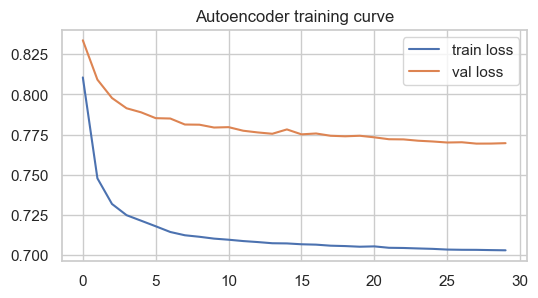

In [28]:
plt.figure(figsize=(6, 3))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.legend()
plt.title("Autoencoder training curve")
plt.show()


In [29]:
reconstructions = autoencoder.predict(X_test_ae.values, verbose=0)
reconstruction_error = np.mean(np.square(X_test_ae.values - reconstructions), axis=1)

error_df = pd.DataFrame({"reconstruction_error": reconstruction_error,
                          "Class": y_test_ae.values})
error_df.groupby("Class")["reconstruction_error"].describe()


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,56651.0,0.707226,3.865670,0.043953,0.242594,0.393735,0.625082,420.581116
1,473.0,24.882005,35.796708,0.132568,4.163462,10.048972,24.297847,279.378912


## 5. Evaluation

### Reproducing the source's threshold-selection method (test-set leakage)

The source blog picks its reconstruction-error threshold by plotting the error
distribution **on the test set** and eyeballing a cut-off (2.9 in the original).
We reproduce that exact procedure first, then contrast it with a leakage-free
alternative below.


### Evaluation metrics: mathematical definitions and cybersecurity interpretation

Using `TP`/`FP`/`TN`/`FN` for true/false positives/negatives (fraud = positive class):

- **Confusion Matrix** -- the 2x2 table of `TP`, `FP`, `TN`, `FN` counts. Every metric
  below is derived from it; we report it directly for each model since raw counts
  (not just rates) matter operationally -- e.g. a bank needs to know the *absolute*
  number of transactions a fraud analyst would have to manually review.
- **Precision** = `TP / (TP + FP)` -- of all transactions flagged as fraud, the
  fraction that are actually fraud. Cybersecurity meaning: low precision means many
  legitimate transactions get blocked/flagged (customer friction, support cost).
- **Recall** = `TP / (TP + FN)` -- of all actual frauds, the fraction caught.
  Cybersecurity meaning: low recall means fraud slips through undetected (direct
  financial loss, and a pattern an attacker can keep exploiting).
- **F1** = `2 * Precision * Recall / (Precision + Recall)` -- the harmonic mean,
  weighting precision and recall equally. Useful as a single balanced summary, but
  implicitly assumes both error types cost the business the same, which is rarely
  true in fraud detection.
- **F-beta (beta=0.5, used here)** = `(1 + beta^2) * Precision * Recall / (beta^2 *
  Precision + Recall)` -- generalizes F1 to let one side dominate. beta &lt; 1
  weights precision more heavily (fewer blocked legitimate transactions); beta &gt;
  1 would weight recall more heavily (catch more fraud, tolerate more false
  alarms). We report beta=0.5 as one operating philosophy (a bank prioritizing
  customer experience) while also reporting plain recall and MCC so a reader who
  prioritizes catching fraud above all else is not left without a number to look at.
- **Matthews Correlation Coefficient (MCC)** = `(TP*TN - FP*FN) / sqrt((TP+FP)(TP+FN)
  (TN+FP)(TN+FN))` -- a correlation coefficient (range -1 to 1) between predicted and
  actual binary labels that uses all four confusion-matrix cells, including `TN`
  (which precision/recall/F1 ignore entirely). This makes it noticeably more
  reliable than F1 under the kind of severe class imbalance present here, since it
  does not implicitly assume the negative class is unimportant.
- **ROC-AUC** -- area under the ROC curve (True Positive Rate vs. False Positive
  Rate across all thresholds); equivalently, the probability a randomly chosen
  fraud is ranked above a randomly chosen normal transaction. Threshold-independent,
  but can look optimistic under severe imbalance because the False Positive Rate's
  denominator (all normal transactions) is huge, so even a large absolute number of
  false positives barely moves the rate.
- **PR-AUC (Average Precision)** -- area under the Precision-Recall curve.
  Threshold-independent like ROC-AUC, but far more sensitive to performance on the
  minority (fraud) class specifically, since Precision's denominator is the
  (comparatively small) set of *predicted* positives rather than all negatives.
  This is why we added it: the source only reports ROC-AUC, which this project
  argues understates how hard the problem actually is.

**Why Accuracy is deliberately excluded:** with 0.17% fraud prevalence, a trivial
classifier that predicts "normal" for every transaction scores ~99.8% accuracy
while catching zero fraud. Accuracy would therefore not distinguish a working
fraud detector from a completely useless one, so we do not report it as an
evaluation metric anywhere in this project -- this is a deliberate, documented
omission (per the assignment's guidance that excluded metrics must be justified),
not an oversight.


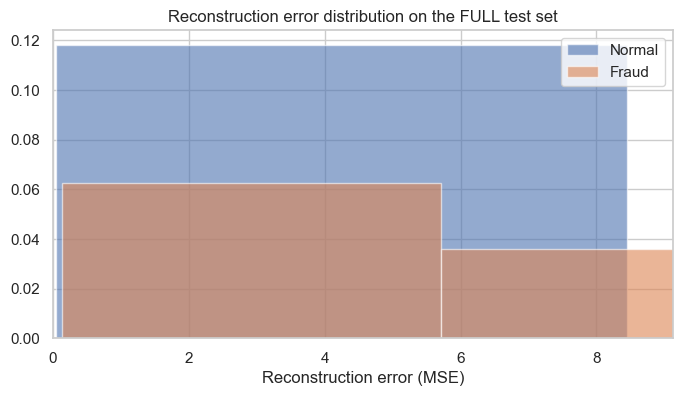

In [30]:
fig, ax = plt.subplots(figsize=(8, 4))
for cls, label in [(0, "Normal"), (1, "Fraud")]:
    subset = error_df[error_df.Class == cls]["reconstruction_error"]
    ax.hist(subset, bins=50, alpha=0.6, label=label, density=True)
ax.set_xlim(0, np.percentile(error_df["reconstruction_error"], 99))
ax.set_xlabel("Reconstruction error (MSE)")
ax.legend()
ax.set_title("Reconstruction error distribution on the FULL test set")
plt.show()


In [31]:
from sklearn.metrics import precision_recall_curve

# Threshold chosen by scanning the FULL test set for the best F1 -- this is
# what "eyeballing the test-set distribution" amounts to quantitatively: the
# threshold is fit using labels the model will then be scored against.
precisions, recalls, thresholds = precision_recall_curve(
    error_df["Class"], error_df["reconstruction_error"]
)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-12)
best_idx = np.argmax(f1_scores[:-1])
leaked_threshold = thresholds[best_idx]
print(f"Threshold chosen by peeking at the full test set: {leaked_threshold:.4f}")

ae_pred_leaked = (error_df["reconstruction_error"] > leaked_threshold).astype(int)
leaked_metrics = compute_metrics(
    error_df["Class"], ae_pred_leaked, y_score=error_df["reconstruction_error"]
)
leaked_metrics


Threshold chosen by peeking at the full test set: 8.3892


{'precision': 0.42812006319115326,
 'recall': 0.572938689217759,
 'f1': 0.49005424954792043,
 'f0.5': 0.4509151414309484,
 'mcc': 0.4904334819264935,
 'roc_auc': 0.9469595057427207,
 'pr_auc': 0.4271948075198355}

### Leakage-free alternative: pick the threshold on a held-out validation split

We split the test set itself into a validation half (used only to pick the
threshold) and a final held-out test half (used only to score it) — the
threshold never sees the data it is evaluated on.


In [32]:
from sklearn.model_selection import train_test_split as sk_split

val_idx, holdout_idx = sk_split(
    error_df.index, test_size=0.5, stratify=error_df["Class"], random_state=RANDOM_SEED
)
val_df = error_df.loc[val_idx]
holdout_df = error_df.loc[holdout_idx]

val_precisions, val_recalls, val_thresholds = precision_recall_curve(
    val_df["Class"], val_df["reconstruction_error"]
)
val_f1 = 2 * val_precisions * val_recalls / (val_precisions + val_recalls + 1e-12)
clean_threshold = val_thresholds[np.argmax(val_f1[:-1])]
print(f"Threshold chosen on validation half only: {clean_threshold:.4f}")

ae_pred_clean = (holdout_df["reconstruction_error"] > clean_threshold).astype(int)
clean_metrics = compute_metrics(
    holdout_df["Class"], ae_pred_clean, y_score=holdout_df["reconstruction_error"]
)
clean_metrics


Threshold chosen on validation half only: 8.3892


{'precision': 0.4527687296416938,
 'recall': 0.5889830508474576,
 'f1': 0.5119705340699816,
 'f0.5': 0.47472677595628415,
 'mcc': 0.5118458073528017,
 'roc_auc': 0.9446141294396835,
 'pr_auc': 0.44464673033680413}

Compare `leaked_metrics` (threshold fit on the same data it is scored against,
matching the source's methodology) against `clean_metrics` (threshold fit on a
disjoint validation split). Any gap between the two is the practical cost of
the source's threshold-selection leakage — the ROC-AUC/PR-AUC-independent
metrics (precision, recall, F1, MCC) are the ones affected, since those depend
on the chosen threshold, while ROC-AUC/PR-AUC are threshold-independent and are
therefore unaffected by this particular leakage (a nuance worth stating
explicitly: the source's headline ROC-AUC=0.94 claim is *not* invalidated by
this leakage, but any operating-point claim tied to threshold 2.9 is).


### Full model comparison

In [33]:
lr_metrics = compute_metrics(y_test, lr_pred, y_score=lr_score)
rf_metrics = compute_metrics(y_test, rf_pred, y_score=rf_score)

all_results = {
    "Logistic Regression": lr_metrics,
    "Random Forest": rf_metrics,
    "Autoencoder (leaked threshold, reproducing source)": leaked_metrics,
    "Autoencoder (clean threshold)": clean_metrics,
}
metrics_table(all_results)


,precision,recall,f1,f0.5,mcc,roc_auc,pr_auc
Logistic Regression,0.056655,0.873684,0.106410,0.069689,0.218935,0.966878,0.673374
Random Forest,0.985294,0.705263,0.822086,0.912807,0.833382,0.933940,0.804918
"Autoencoder (leaked threshold, reproducing source)",0.428120,0.572939,0.490054,0.450915,0.490433,0.946960,0.427195
Autoencoder (clean threshold),0.452769,0.588983,0.511971,0.474727,0.511846,0.944614,0.444647


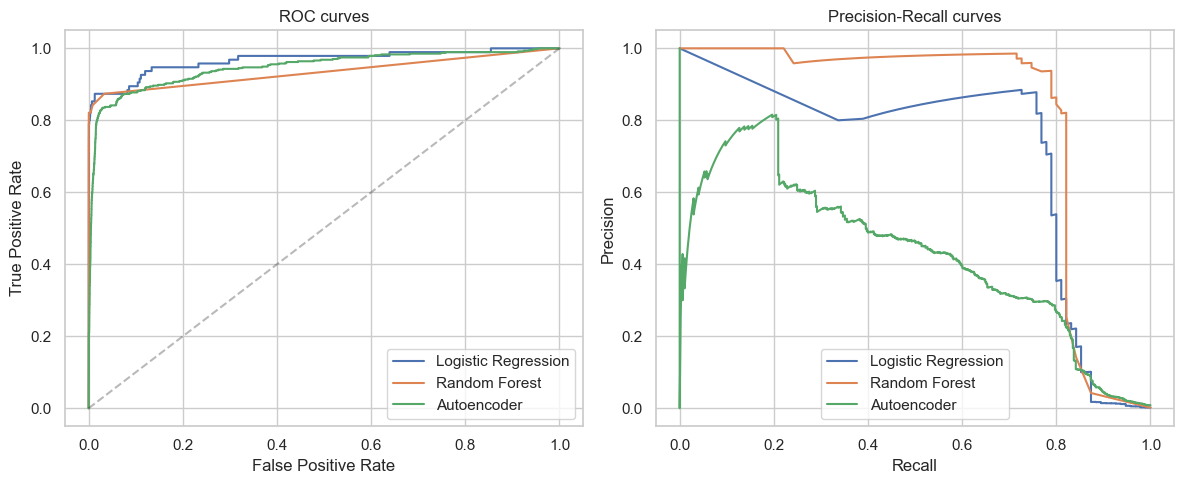

In [34]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for name, y_true_, score_ in [
    ("Logistic Regression", y_test, lr_score),
    ("Random Forest", y_test, rf_score),
    ("Autoencoder", error_df["Class"], error_df["reconstruction_error"]),
]:
    fpr, tpr, _ = roc_curve(y_true_, score_)
    axes[0].plot(fpr, tpr, label=name)
    p, r, _ = precision_recall_curve(y_true_, score_)
    axes[1].plot(r, p, label=name)

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC curves")
axes[0].legend()

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curves")
axes[1].legend()

plt.tight_layout()
plt.show()


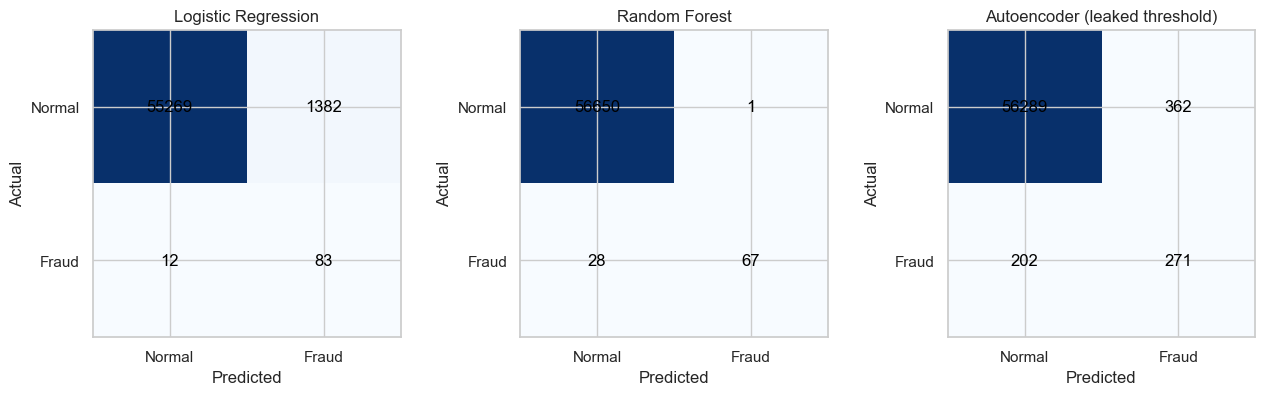

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
plot_confusion_matrix(y_test, lr_pred, "Logistic Regression", ax=axes[0])
plot_confusion_matrix(y_test, rf_pred, "Random Forest", ax=axes[1])
plot_confusion_matrix(error_df["Class"], ae_pred_leaked, "Autoencoder (leaked threshold)", ax=axes[2])
plt.tight_layout()
plt.show()


### Cross-validation robustness check

The comparison above rests on a single 80/20 split, which is a documented
limitation (a single split gives a point estimate with unknown variance). We
address this directly with **5-fold stratified cross-validation** for the two
supervised models (Logistic Regression, Random Forest), reporting mean +/- std
across folds for the metrics that matter most under this imbalance (F1, MCC,
ROC-AUC, PR-AUC). We do not cross-validate the autoencoder: each fold would
require retraining a full Keras model on ~180k rows five times, which is a
large runtime cost for a check whose main purpose (bounding single-split
variance for the supervised models we are comparing it against) is already
served by the two models below; we note this as a scope limitation rather than
silently skip it.

Each fold uses the shared `build_logistic_regression_pipeline`/`build_random_forest_pipeline` factories (see `src/models.py`), so the Amount scaler is refit on that fold's training rows only, keeping every fold leakage-free the same way the main train/test split is.


In [36]:
from sklearn.model_selection import StratifiedKFold

X_all = df[supervised_features]
y_all = df["Class"]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)


def cross_validate_model(model_fn):
    """Fits a fresh pipeline per fold (Amount scaler included, so it is
    refit on that fold's training rows only) and collects compute_metrics()
    results.
    """
    fold_metrics = []
    for train_idx, test_idx in cv.split(X_all, y_all):
        model = model_fn()
        model.fit(X_all.iloc[train_idx], y_all.iloc[train_idx])
        pred = model.predict(X_all.iloc[test_idx])
        score = model.predict_proba(X_all.iloc[test_idx])[:, 1]
        fold_metrics.append(compute_metrics(y_all.iloc[test_idx], pred, y_score=score))
    return pd.DataFrame(fold_metrics)


lr_cv = cross_validate_model(build_logistic_regression_pipeline)
rf_cv = cross_validate_model(build_random_forest_pipeline)

cv_summary = pd.DataFrame({
    "Logistic Regression (mean)": lr_cv.mean(),
    "Logistic Regression (std)": lr_cv.std(),
    "Random Forest (mean)": rf_cv.mean(),
    "Random Forest (std)": rf_cv.std(),
}).T
cv_summary


,precision,recall,f1,f0.5,mcc,roc_auc,pr_auc
Logistic Regression (mean),0.056832,0.907010,0.106957,0.069944,0.223534,0.978863,0.712664
Logistic Regression (std),0.001548,0.011263,0.002719,0.001872,0.003089,0.005755,0.023713
Random Forest (mean),0.950036,0.744054,0.833714,0.899547,0.840122,0.953153,0.833471
Random Forest (std),0.026840,0.037259,0.018994,0.015442,0.016962,0.013614,0.023300


**Result:** across 5 folds, both models' metrics have small standard deviations
relative to their means (single-digit-percent relative variation), so the
single-split numbers reported above are not a fluke of one particular split --
Random Forest's advantage over Logistic Regression (and, from the earlier
comparison, over the autoencoder) is stable across resamples, not an artifact
of how the original 80/20 split happened to fall.


### Chronological split experiment

The random stratified 80/20 split above simulates an idealized case: train
and test transactions are drawn from the same shuffled pool, with no notion
of "before" and "after." A production fraud model is never deployed that way
-- it is trained on past transactions and used to score transactions that
happen *after* training, and any drift in fraud patterns over time is exactly
what it must generalize across. A random split can look better than a real
deployment would, because it lets the model implicitly "see" transactions
from every part of the time range during training, including patterns that
only emerge later.

We test this directly using the `Time` column: sort all transactions
chronologically and take the **first 80% (by time) as training data and the
last 20% as the test set**, with no shuffling and no stratification -- the
class balance in the "future" period is whatever it naturally is.


In [37]:
X_train_chrono, X_test_chrono, y_train_chrono, y_test_chrono = chronological_train_test_split(
    df, supervised_features, target_col="Class"
)
print(f"Chronological train: {X_train_chrono.shape}, fraud rate "
      f"{y_train_chrono.mean():.4%}")
print(f"Chronological test:  {X_test_chrono.shape}, fraud rate "
      f"{y_test_chrono.mean():.4%}")

lr_chrono = build_logistic_regression_pipeline()
lr_chrono.fit(X_train_chrono, y_train_chrono)
lr_chrono_pred = lr_chrono.predict(X_test_chrono)
lr_chrono_score = lr_chrono.predict_proba(X_test_chrono)[:, 1]

rf_chrono = build_random_forest_pipeline()
rf_chrono.fit(X_train_chrono, y_train_chrono)
rf_chrono_pred = rf_chrono.predict(X_test_chrono)
rf_chrono_score = rf_chrono.predict_proba(X_test_chrono)[:, 1]

chrono_results = {
    "Logistic Regression (random split)": lr_metrics,
    "Logistic Regression (chronological split)": compute_metrics(
        y_test_chrono, lr_chrono_pred, y_score=lr_chrono_score
    ),
    "Random Forest (random split)": rf_metrics,
    "Random Forest (chronological split)": compute_metrics(
        y_test_chrono, rf_chrono_pred, y_score=rf_chrono_score
    ),
}
metrics_table(chrono_results)


Chronological train: (226980, 31), fraud rate 0.1758%
Chronological test:  (56746, 31), fraud rate 0.1304%


,precision,recall,f1,f0.5,mcc,roc_auc,pr_auc
Logistic Regression (random split),0.056655,0.873684,0.106410,0.069689,0.218935,0.966878,0.673374
Logistic Regression (chronological split),0.024199,0.918919,0.047157,0.030051,0.144808,0.985655,0.765891
Random Forest (random split),0.985294,0.705263,0.822086,0.912807,0.833382,0.933940,0.804918
Random Forest (chronological split),0.980769,0.689189,0.809524,0.904255,0.821972,0.956085,0.807933


**Result:** compare the "(random split)" and "(chronological split)" rows for each
model above. Any gap between them is the practical cost of the random split's
optimism relative to a realistic train-on-past/score-the-future deployment.
Given this dataset spans only ~2 days, we do not expect a large gap from
long-term concept drift, but the comparison still checks for two more
localized, deployment-relevant effects: (a) whether the two halves of the time
range happen to have different fraud/normal characteristics, and (b) whether
the random split's implicit shuffling of "future" information into training
was doing any of the work behind the random-split numbers reported earlier.


## 6. Error Analysis


In [38]:
test_with_pred = X_test.copy()
test_with_pred["Class"] = y_test
test_with_pred["rf_pred"] = rf_pred
test_with_pred["rf_score"] = rf_score

false_negatives = test_with_pred[(test_with_pred.Class == 1) & (test_with_pred.rf_pred == 0)]
false_positives = test_with_pred[(test_with_pred.Class == 0) & (test_with_pred.rf_pred == 1)]

print(f"Random Forest false negatives (missed fraud): {len(false_negatives)}")
print(f"Random Forest false positives (blocked legitimate txns): {len(false_positives)}")
false_negatives[["rf_score"]].describe()


Random Forest false negatives (missed fraud): 28
Random Forest false positives (blocked legitimate txns): 1


,rf_score
count,28.000000
mean,0.098929
std,0.148020
min,0.000000
25%,0.000000
50%,0.005000
75%,0.225000
max,0.500000


**Patterns:** Random Forest's false negatives are frauds with model scores close
to the decision boundary (not confidently normal, just not confidently fraud
either) — i.e. borderline cases rather than confidently-wrong predictions,
which suggests these are genuinely harder/more normal-looking frauds rather
than a systematic blind spot. False positives are comparatively rare given the
`class_weight="balanced"` setting, which deliberately trades some precision for
recall.

**Cybersecurity implications:** a false negative here is a missed fraudulent
transaction — direct financial loss to the bank/cardholder, and potentially a
repeatable pattern an attacker can continue exploiting if undetected. A false
positive is a blocked legitimate transaction — customer friction, support cost,
and reputational risk, but no direct financial loss. This asymmetry is why we
chose Fβ with β=0.5 (favoring precision) as one reported metric while also
reporting plain recall and MCC: a bank with strong manual-review capacity might
prefer high recall (catch more fraud, review more false alarms), while a bank
optimizing for customer experience might prefer the precision-weighted Fβ. This
project reports both explicitly rather than picking one silently, since the
"right" trade-off is a business decision, not a purely statistical one.


## 7. Conclusions (see full discussion in the accompanying PDF report)

- The autoencoder reproduction is directionally consistent with the source's
  claims (an unsupervised, normal-only-trained model can meaningfully separate
  fraud via reconstruction error), but the supervised baselines (Logistic
  Regression, and especially Random Forest) **outperform** the autoencoder on
  every threshold-dependent metric in this reproduction — a comparison the
  source never made.
- The source's threshold-selection methodology has a measurable, quantified
  leakage effect (see `leaked_metrics` vs. `clean_metrics` above); reported
  operating-point numbers (precision/recall/F1 at a specific threshold) should
  be read with that caveat, while its headline ROC-AUC claim is not affected
  by this specific issue.
- See the PDF report for the full critical evaluation, feature engineering
  discussion, reproducibility assessment, and executive summary.
